<a href="https://colab.research.google.com/github/pmhiremath/-bank-churn-visual-eda/blob/main/statistics_ds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

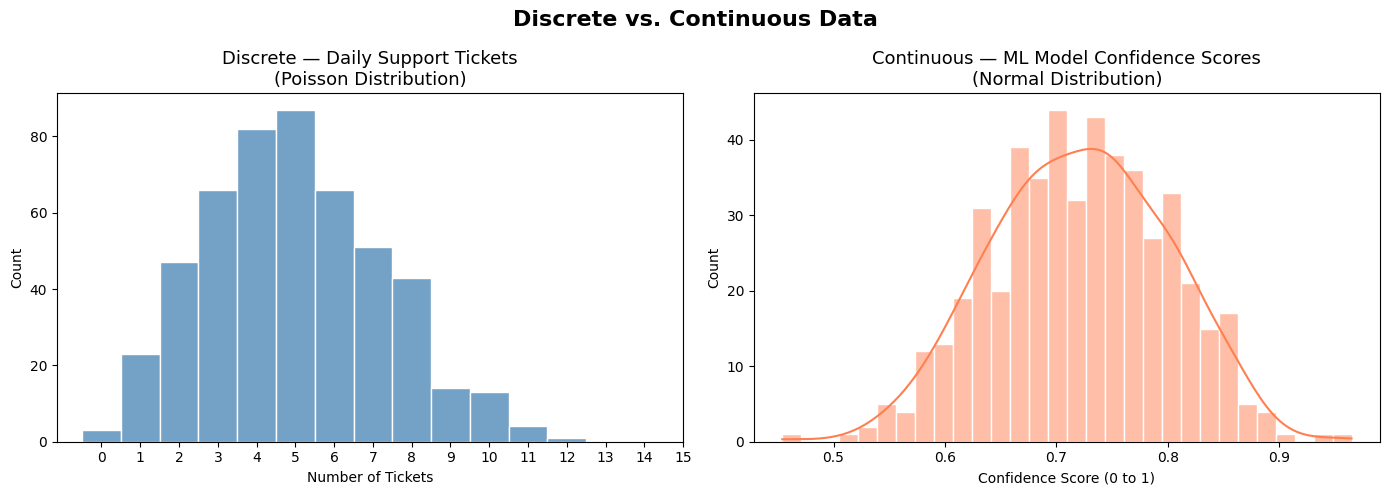

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Discrete vs. Continuous Data", fontsize=16, fontweight='bold')

# --- DISCRETE: Number of support tickets per day ---
discrete_data = np.random.poisson(lam=5, size=500)  # avg 5 tickets/day

axes[0].set_title("Discrete — Daily Support Tickets\n(Poisson Distribution)", fontsize=13)
sns.histplot(
    discrete_data,
    bins=range(0, 16),   # integer bins only
    discrete=True,
    color='steelblue',
    edgecolor='white',
    ax=axes[0]
)
axes[0].set_xlabel("Number of Tickets")
axes[0].set_ylabel("Count")
axes[0].set_xticks(range(0, 16))

# --- CONTINUOUS: Model prediction confidence scores ---
continuous_data = np.random.normal(loc=0.72, scale=0.08, size=500)  # centered at 72%
continuous_data = np.clip(continuous_data, 0, 1)  # keep in [0,1]

axes[1].set_title("Continuous — ML Model Confidence Scores\n(Normal Distribution)", fontsize=13)
sns.histplot(
    continuous_data,
    bins=30,
    kde=True,             # smooth density curve — valid for continuous
    color='coral',
    edgecolor='white',
    ax=axes[1]
)
axes[1].set_xlabel("Confidence Score (0 to 1)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("discrete_vs_continuous.png", dpi=150)
plt.show()

Q1: 28.7 min
Q3: 42.5 min
IQR: 13.8 min
Lower fence: 8.1 min
Upper fence: 63.1 min

Metric                   Before      After
----------------------------------------
Mean                       42.0       35.1
Median                     35.7       35.2
Total Orders                500        477


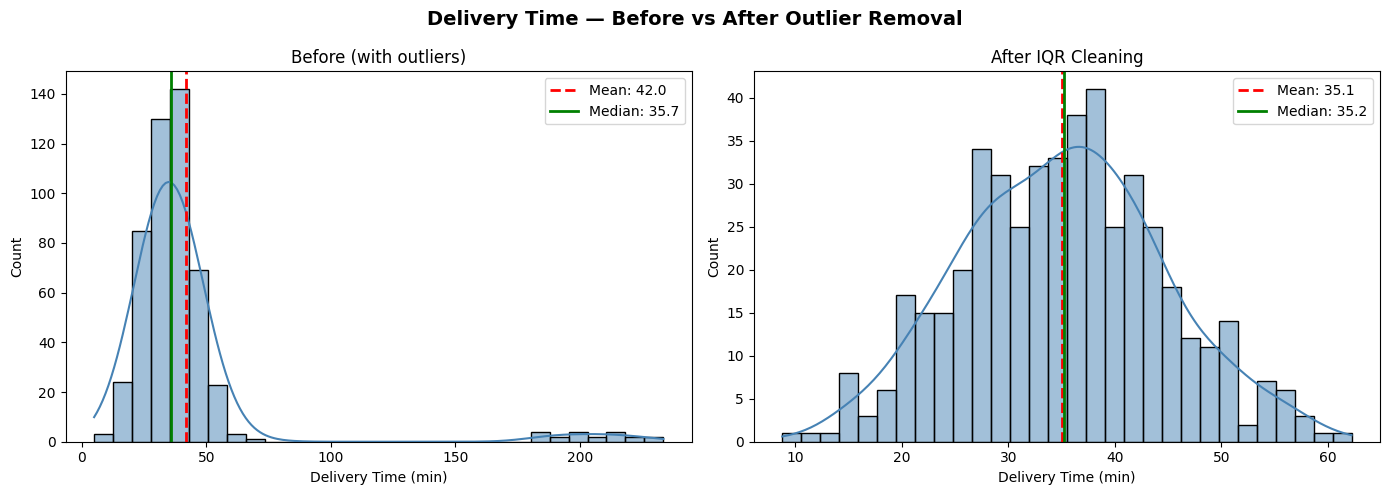

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Simulate delivery times (minutes)
normal_orders = np.random.normal(loc=35, scale=10, size=480)
outlier_orders = np.random.uniform(180, 240, size=20)  # your 20 bad orders
delivery_times = np.concatenate([normal_orders, outlier_orders])
delivery_times = np.clip(delivery_times, 5, 300)

df = pd.DataFrame({'delivery_min': delivery_times})

# --- BEFORE Cleaning ---
mean_before = df['delivery_min'].mean()
median_before = df['delivery_min'].median()

# --- IQR Outlier Removal ---
Q1 = df['delivery_min'].quantile(0.25)
Q3 = df['delivery_min'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.1f} min")
print(f"Q3: {Q3:.1f} min")
print(f"IQR: {IQR:.1f} min")
print(f"Lower fence: {lower:.1f} min")
print(f"Upper fence: {upper:.1f} min")

df_clean = df[(df['delivery_min'] >= lower) &
              (df['delivery_min'] <= upper)]

# --- AFTER Cleaning ---
mean_after = df_clean['delivery_min'].mean()
median_after = df_clean['delivery_min'].median()

print(f"\n{'Metric':<20} {'Before':>10} {'After':>10}")
print(f"{'-'*40}")
print(f"{'Mean':<20} {mean_before:>10.1f} {mean_after:>10.1f}")
print(f"{'Median':<20} {median_before:>10.1f} {median_after:>10.1f}")
print(f"{'Total Orders':<20} {len(df):>10} {len(df_clean):>10}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Delivery Time — Before vs After Outlier Removal",
             fontsize=14, fontweight='bold')

for ax, data, title in zip(axes,
                            [df['delivery_min'], df_clean['delivery_min']],
                            ['Before (with outliers)', 'After IQR Cleaning']):
    sns.histplot(data, bins=30, kde=True, ax=ax, color='steelblue')
    ax.axvline(data.mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle='-',
               linewidth=2, label=f'Median: {data.median():.1f}')
    ax.set_title(title)
    ax.set_xlabel("Delivery Time (min)")
    ax.legend()

plt.tight_layout()

Driver A → Mean: 30.0  Variance: 0.4  Std Dev: 0.6
Driver B → Mean: 32.0  Variance: 446.0  Std Dev: 21.1


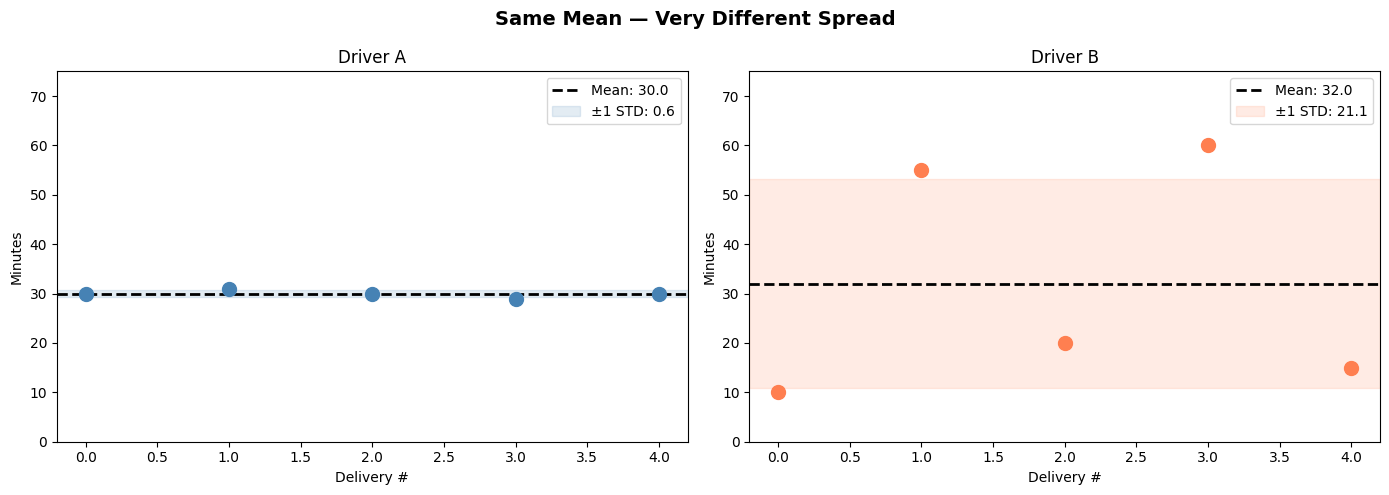

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

driver_a = [30, 31, 30, 29, 30]
driver_b = [10, 55, 20, 60, 15]

for name, data in [("Driver A", driver_a), ("Driver B", driver_b)]:
    mean = np.mean(data)
    var  = np.var(data)
    std  = np.std(data)
    print(f"{name} → Mean: {mean:.1f}  Variance: {var:.1f}  Std Dev: {std:.1f}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Same Mean — Very Different Spread",
             fontsize=14, fontweight='bold')

for ax, data, name, color in zip(
        axes,
        [driver_a, driver_b],
        ["Driver A", "Driver B"],
        ["steelblue", "coral"]):

    mean = np.mean(data)
    std  = np.std(data)

    ax.scatter(range(len(data)), data,
               color=color, s=100, zorder=5)
    ax.axhline(mean, color='black', linestyle='--',
               linewidth=2, label=f'Mean: {mean:.1f}')
    ax.axhspan(mean - std, mean + std,
               alpha=0.15, color=color,
               label=f'±1 STD: {std:.1f}')
    ax.set_title(f"{name}")
    ax.set_xlabel("Delivery #")
    ax.set_ylabel("Minutes")
    ax.set_ylim(0, 75)
    ax.legend()

plt.tight_layout()
plt.show()

Expected Revenue per email: $8.00


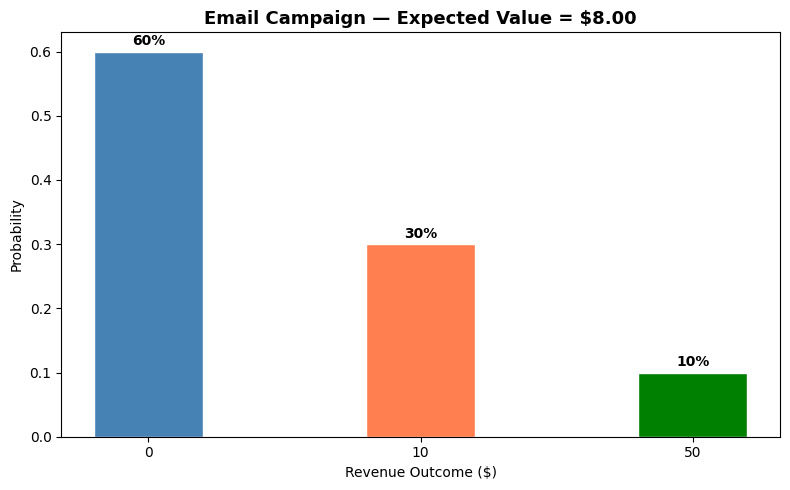

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

outcomes     = [0,    10,   50 ]
probabilities= [0.60, 0.30, 0.10]

# Expected Value
ev = sum(x * p for x, p in zip(outcomes, probabilities))
print(f"Expected Revenue per email: ${ev:.2f}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue', 'coral', 'green']
bars = ax.bar([str(o) for o in outcomes],
               probabilities,
               color=colors,
               edgecolor='white',
               width=0.4)

ax.set_title(f"Email Campaign — Expected Value = ${ev:.2f}",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Revenue Outcome ($)")
ax.set_ylabel("Probability")

for bar, prob in zip(bars, probabilities):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{prob:.0%}',
            ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


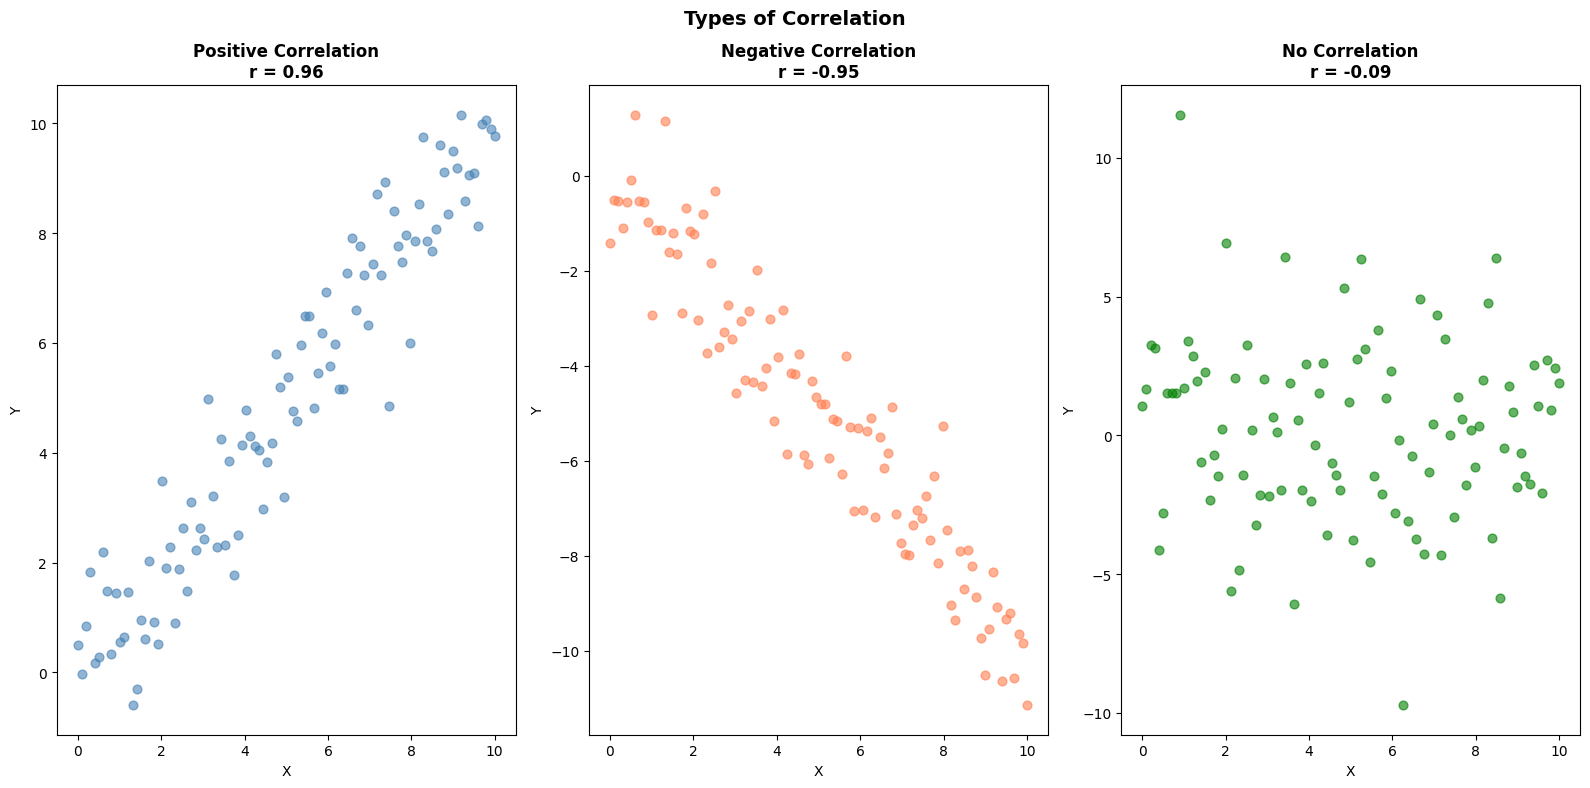

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 100

# Three types of correlation
x = np.linspace(0, 10, n)

positive = x + np.random.normal(0, 1, n)    # delivery speed vs rating
negative = -x + np.random.normal(0, 1, n)   # wait time vs satisfaction
no_corr  = np.random.normal(0, 3, n)        # shoe size vs salary

fig, axes = plt.subplots(1, 3, figsize=(16, 8))
fig.suptitle("Types of Correlation", fontsize=14, fontweight='bold')

for ax, y, title, color in zip(
        axes,
        [positive, negative, no_corr],
        ['Positive Correlation', 'Negative Correlation', 'No Correlation'],
        ['steelblue', 'coral', 'green']):

    r = np.corrcoef(x, y)[0, 1]
    ax.scatter(x, y, color=color, alpha=0.6, s=40)
    ax.set_title(f"{title}\nr = {r:.2f}", fontsize=12, fontweight='bold')
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
plt.tight_layout()
plt.show()

                   delivery_time  distance_km  customer_rating  order_value  \
delivery_time               1.00         0.59            -0.64        -0.02   
distance_km                 0.59         1.00            -0.37        -0.13   
customer_rating            -0.64        -0.37             1.00         0.03   
order_value                -0.02        -0.13             0.03         1.00   
driver_experience          -0.10        -0.14             0.14         0.38   

                   driver_experience  
delivery_time                  -0.10  
distance_km                    -0.14  
customer_rating                 0.14  
order_value                     0.38  
driver_experience               1.00  


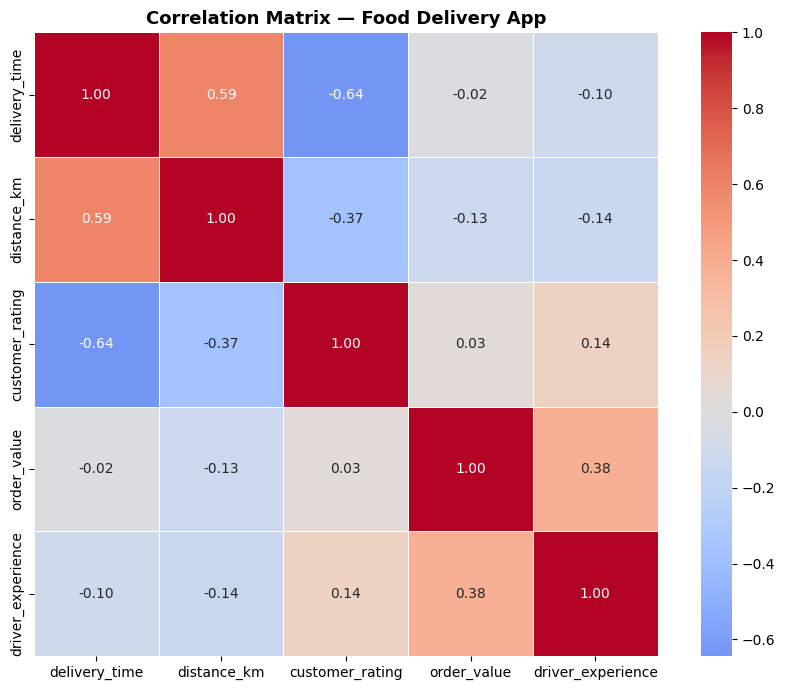

In [ ]:
 import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
n = 200

# Simulate a real DS dataset — food delivery app
df = pd.DataFrame({
    'delivery_time':     np.random.normal(35, 10, n),
    'distance_km':       np.random.normal(5, 2, n),
    'customer_rating':   np.random.normal(4, 0.5, n),
    'order_value':       np.random.normal(25, 8, n),
    'driver_experience': np.random.normal(3, 1, n)
})

# Make realistic relationships
df['delivery_time'] = df['delivery_time'] + df['distance_km'] * 3
df['customer_rating'] = 5 - (df['delivery_time'] * 0.02) + \
                        np.random.normal(0, 0.3, n)
df['order_value'] = df['order_value'] + df['driver_experience'] * 2

# --- Correlation Matrix ---
corr_matrix = df.corr()
print(corr_matrix.round(2))

# --- Heatmap ---
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,           # show numbers inside
    fmt='.2f',            # 2 decimal places
    cmap='coolwarm',      # blue=negative, red=positive
    center=0,             # white = 0 correlation
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix — Food Delivery App",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


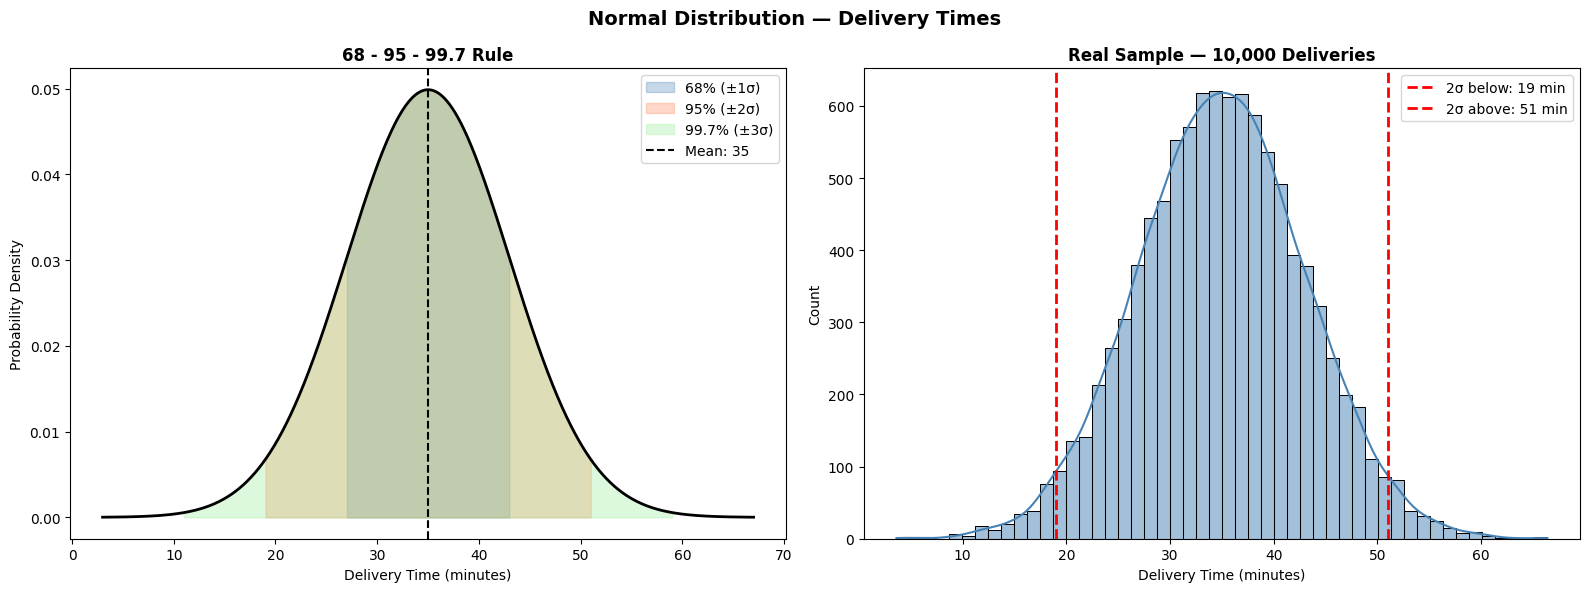

Mean: 35 min
Std Dev: 8 min
68% of deliveries: 27 to 43 min
95% of deliveries: 19 to 51 min
99.7% of deliveries: 11 to 59 min

Delivery > 59 min (beyond 3σ) → OUTLIER


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)

# Delivery times — normally distributed
mean = 35    # average 35 minutes
std  = 8     # std dev 8 minutes

data = np.random.normal(loc=mean, scale=std, size=10000)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Normal Distribution — Delivery Times",
             fontsize=14, fontweight='bold')

# --- Plot 1: The Bell Curve with 68-95-99.7 rule ---
ax = axes[0]
x = np.linspace(mean - 4*std, mean + 4*std, 1000)
y = stats.norm.pdf(x, mean, std)

ax.plot(x, y, 'black', linewidth=2)

# shade regions
for sigma, color, label in [
    (1, 'steelblue',  '68% (±1σ)'),
    (2, 'coral',      '95% (±2σ)'),
    (3, 'lightgreen', '99.7% (±3σ)')]:
    ax.fill_between(x, y,
                    where=(x >= mean - sigma*std) &
                          (x <= mean + sigma*std),
                    alpha=0.3, color=color, label=label)

ax.axvline(mean, color='black', linestyle='--',
           linewidth=1.5, label=f'Mean: {mean}')
ax.set_title("68 - 95 - 99.7 Rule", fontsize=12, fontweight='bold')
ax.set_xlabel("Delivery Time (minutes)")
ax.set_ylabel("Probability Density")
ax.legend()

# --- Plot 2: Real data histogram ---
ax2 = axes[1]
sns.histplot(data, bins=50, kde=True,
             color='steelblue', ax=ax2)
ax2.axvline(mean - 2*std, color='red', linestyle='--',
            linewidth=2, label=f'2σ below: {mean-2*std} min')
ax2.axvline(mean + 2*std, color='red', linestyle='--',
            linewidth=2, label=f'2σ above: {mean+2*std} min')
ax2.set_title("Real Sample — 10,000 Deliveries",
              fontsize=12, fontweight='bold')
ax2.set_xlabel("Delivery Time (minutes)")
ax2.legend()

plt.tight_layout()
plt.show()

# Key statistics
print(f"Mean: {mean} min")
print(f"Std Dev: {std} min")
print(f"68% of deliveries: {mean-std} to {mean+std} min")
print(f"95% of deliveries: {mean-2*std} to {mean+2*std} min")
print(f"99.7% of deliveries: {mean-3*std} to {mean+3*std} min")
print(f"\nDelivery > 59 min (beyond 3σ) → OUTLIER")

Expected clicks: 200.0
Std Dev: 12.65

P(exactly 200 clicks): 0.0315
P(more than 250 clicks): 0.000051


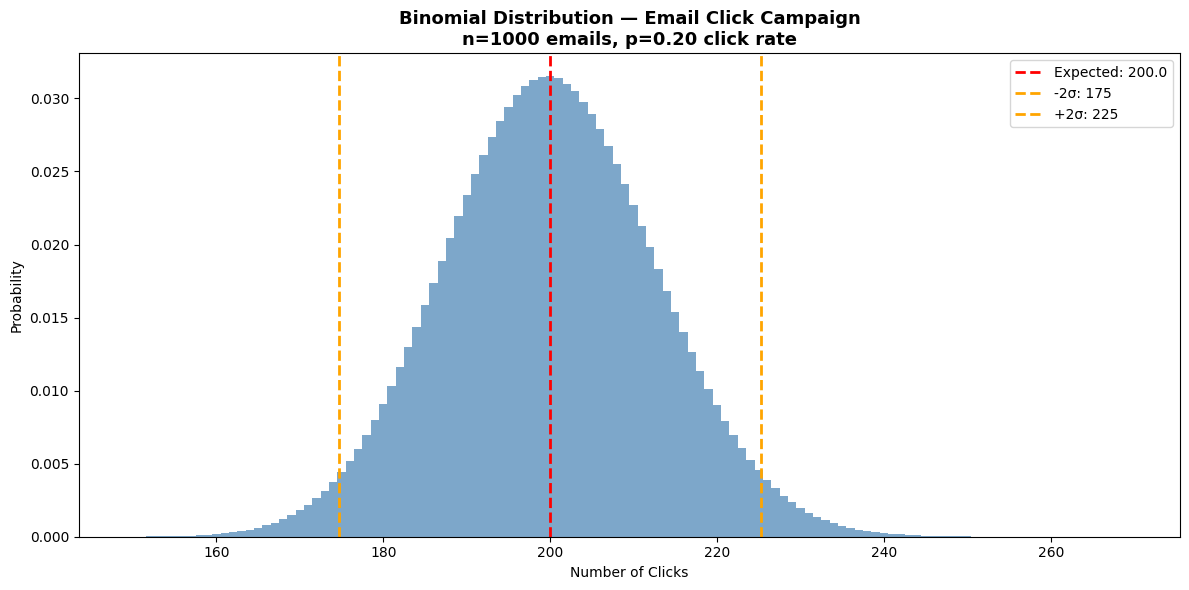

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


n = 1000    # emails sent
p = 0.20    # click probability

# Expected clicks
expected = n * p
std_dev  = np.sqrt(n * p * (1-p))

print(f"Expected clicks: {expected}")
print(f"Std Dev: {std_dev:.2f}")

# Probability of EXACTLY 200 clicks
prob_200 = stats.binom.pmf(k=200, n=n, p=p)
print(f"\nP(exactly 200 clicks): {prob_200:.4f}")

# Probability of MORE than 250 clicks (campaign went viral!)
prob_250_plus = 1 - stats.binom.cdf(k=250, n=n, p=p)
print(f"P(more than 250 clicks): {prob_250_plus:.6f}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

k_values = np.arange(150, 270)
probabilities = stats.binom.pmf(k_values, n, p)

ax.bar(k_values, probabilities,
       color='steelblue', alpha=0.7, width=1)

# Highlight expected value
ax.axvline(expected, color='red', linestyle='--',
           linewidth=2, label=f'Expected: {expected}')

# Highlight ±2 std dev
ax.axvline(expected - 2*std_dev, color='orange',
           linestyle='--', linewidth=2,
           label=f'-2σ: {expected-2*std_dev:.0f}')
ax.axvline(expected + 2*std_dev, color='orange',
           linestyle='--', linewidth=2,
           label=f'+2σ: {expected+2*std_dev:.0f}')

ax.set_title("Binomial Distribution — Email Click Campaign\n"
             "n=1000 emails, p=0.20 click rate",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Number of Clicks")
ax.set_ylabel("Probability")
ax.legend()

plt.tight_layout()
plt.show()

Poisson Distribution — Support Tickets per Hour
Average rate (λ): 8 tickets/hour

P(exactly  0 tickets): 0.0003 (0.03%)
P(exactly  5 tickets): 0.0916 (9.16%)
P(exactly  8 tickets): 0.1396 (13.96%)
P(exactly 10 tickets): 0.0993 (9.93%)
P(exactly 15 tickets): 0.0090 (0.90%)
P(exactly 20 tickets): 0.0002 (0.02%)

P(more than 15 tickets): 0.0082
→ Staff needs to handle surge 0.82% of hours


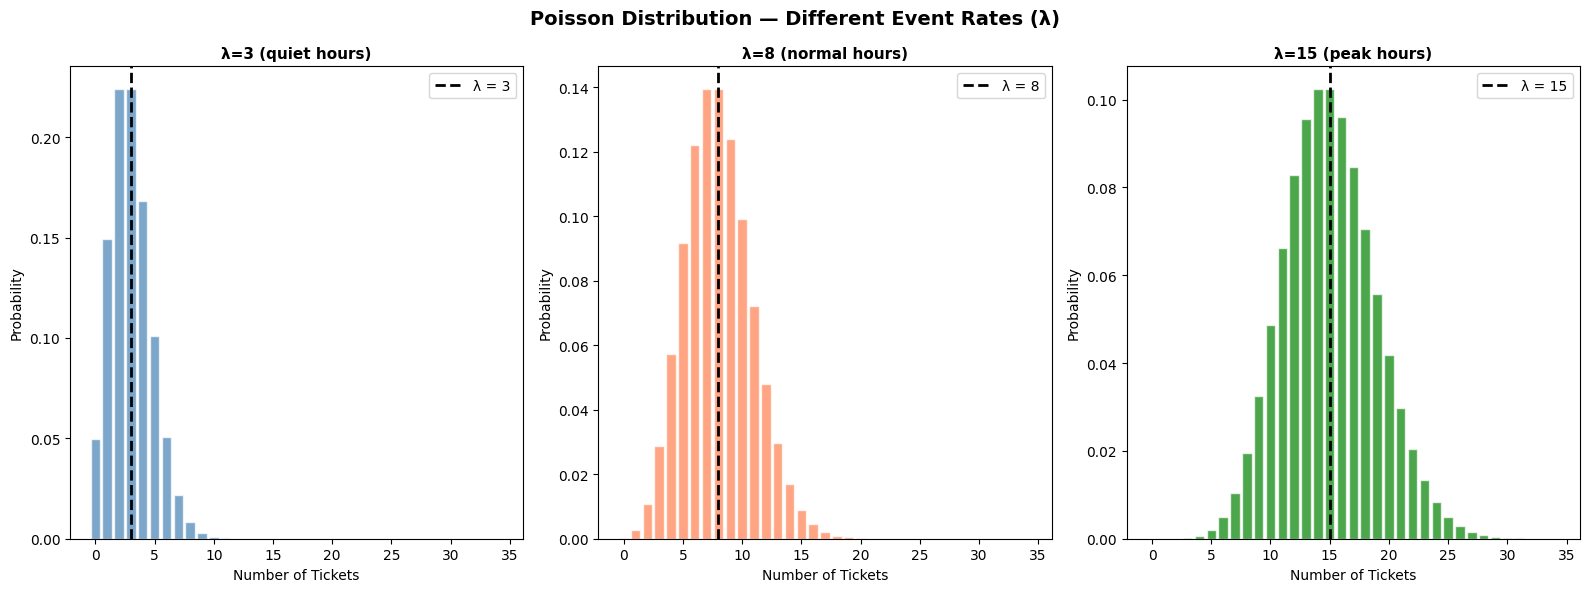

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Support tickets per hour
# Average = 8 tickets/hour
lambda_rate = 8

print("Poisson Distribution — Support Tickets per Hour")
print(f"Average rate (λ): {lambda_rate} tickets/hour\n")

# Key probabilities
for k in [0, 5, 8, 10, 15, 20]:
    prob = stats.poisson.pmf(k=k, mu=lambda_rate)
    print(f"P(exactly {k:2d} tickets): {prob:.4f} ({prob*100:.2f}%)")

# Probability of being overwhelmed (>15 tickets)
prob_overwhelmed = 1 - stats.poisson.cdf(k=15, mu=lambda_rate)
print(f"\nP(more than 15 tickets): {prob_overwhelmed:.4f}")
print(f"→ Staff needs to handle surge {prob_overwhelmed*100:.2f}% of hours")

# --- Plot: Compare different lambda rates ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Poisson Distribution — Different Event Rates (λ)",
             fontsize=14, fontweight='bold')

for ax, lam, title, color in zip(
        axes,
        [3, 8, 15],
        ['λ=3 (quiet hours)',
         'λ=8 (normal hours)',
         'λ=15 (peak hours)'],
        ['steelblue', 'coral', 'green']):

    k_vals = np.arange(0, 35)
    probs  = stats.poisson.pmf(k_vals, mu=lam)

    ax.bar(k_vals, probs, color=color,
           alpha=0.7, width=0.8, edgecolor='white')
    ax.axvline(lam, color='black', linestyle='--',
               linewidth=2, label=f'λ = {lam}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Number of Tickets")
    ax.set_ylabel("Probability")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# === SIMULATE THE POPULATION ===
# Imagine: session duration (seconds) for ALL 1 million users
population = np.random.normal(loc=180, scale=45, size=1_000_000)

population_mean = population.mean()
population_std  = population.std()

print(f"TRUE Population Mean (μ): {population_mean:.2f}s")
print(f"TRUE Population Std  (σ): {population_std:.2f}s")

# === DRAW A SAMPLE (what you'd have in practice) ===
sample = np.random.choice(population, size=500, replace=False)

sample_mean = sample.mean()
sample_std  = sample.std(ddof=1)   # ddof=1 → Bessel's correction for unbiased estimate

print(f"\nSample Mean (x̄): {sample_mean:.2f}s")
print(f"Sample Std  (s):  {sample_std:.2f}s")
print(f"Estimation Error: {abs(sample_mean - population_mean):.2f}s")

# === VISUALIZE ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Population vs. Sample", fontsize=15, fontweight='bold')

# Population
sns.histplot(population, bins=80, ax=axes[0], color='steelblue', alpha=0.6)
axes[0].axvline(population_mean, color='red', linewidth=2, label=f'μ = {population_mean:.1f}')
axes[0].set_title("Population (1,000,000 users)\n[You never have this in practice]")
axes[0].set_xlabel("Session Duration (s)")
axes[0].legend()

# Sample
sns.histplot(sample, bins=40, ax=axes[1], color='coral', alpha=0.7)
axes[1].axvline(sample_mean, color='darkred', linewidth=2, label=f'x̄ = {sample_mean:.1f}')
axes[1].axvline(population_mean, color='blue', linewidth=2, linestyle='--', label=f'μ = {population_mean:.1f}')
axes[1].set_title("Sample (n=500 users)\n[What you actually work with]")
axes[1].set_xlabel("Session Duration (s)")
axes[1].legend()

plt.tight_layout()
plt.savefig("pop_vs_sample.png", dpi=150)
plt.show()

TRUE Population Mean (μ): ₹497.99
Random Sample Mean (x̄):  ₹497.56
Difference from truth:    ₹0.42

Biased Sample Mean (x̄):  ₹1305.10
Difference from truth:    ₹807.12

Stratified Sample Mean:   ₹523.53
Difference from truth:    ₹25.55


/tmp/ipykernel_24215/784807560.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = df.groupby('stratum', observed=True).apply(
/tmp/ipykernel_24215/784807560.py:81: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24215/784807560.py:81: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: Use

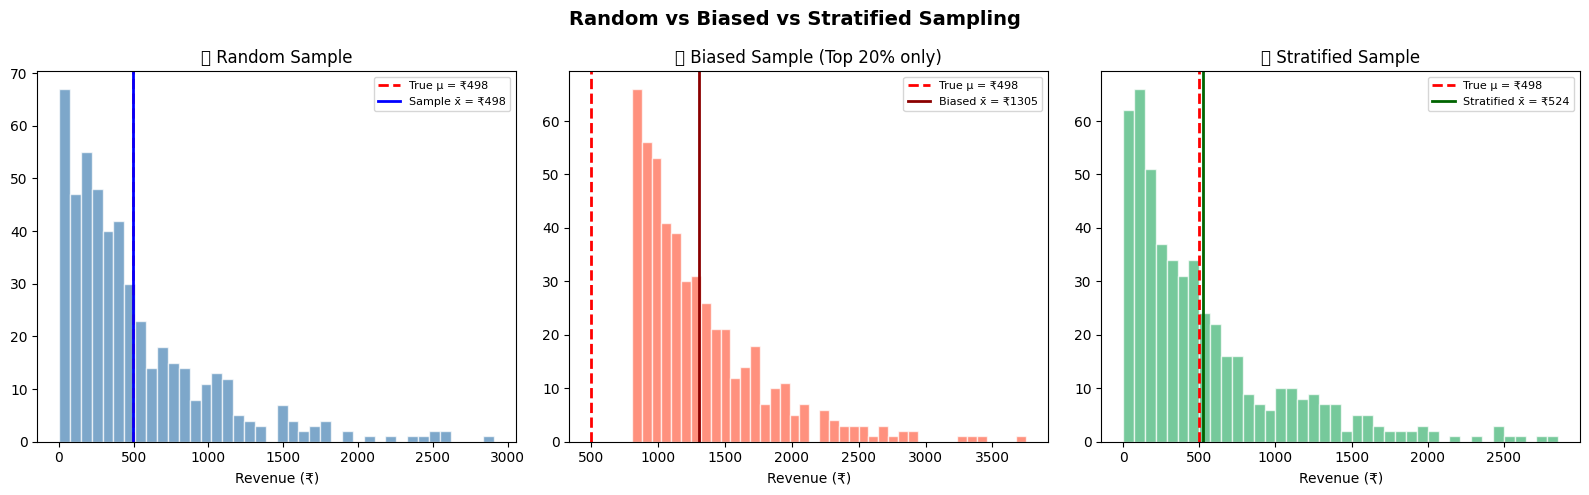

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# ─────────────────────────────────────────
# STEP 1: Simulate a Population
# Imagine: daily revenue (in ₹) of 100,000 customers
# ─────────────────────────────────────────
population_size = 100_000
population = np.random.exponential(scale=500, size=population_size)

population_mean = population.mean()
print(f"TRUE Population Mean (μ): ₹{population_mean:.2f}")
# ─────────────────────────────────────────
# STEP 2: Simple Random Sample
# ─────────────────────────────────────────
sample_size = 500
random_sample = np.random.choice(population, size=sample_size, replace=False)
random_sample_mean = random_sample.mean()
print(f"Random Sample Mean (x̄):  ₹{random_sample_mean:.2f}")
print(f"Difference from truth:    ₹{abs(population_mean - random_sample_mean):.2f}")
# ─────────────────────────────────────────
# STEP 3: Biased Sample
# (Only picking HIGH spenders — top 20%)
# This simulates selection bias
# ─────────────────────────────────────────
threshold = np.percentile(population, 80)  # Top 20%
biased_pool = population[population > threshold]
biased_sample = np.random.choice(biased_pool, size=sample_size, replace=False)
biased_sample_mean = biased_sample.mean()
print(f"\nBiased Sample Mean (x̄):  ₹{biased_sample_mean:.2f}")
print(f"Difference from truth:    ₹{abs(population_mean - biased_sample_mean):.2f}")
# ─────────────────────────────────────────
# STEP 4: Stratified Sampling (ML best practice)
# Split population into Low/Mid/High spenders
# Sample proportionally from each stratum
# ─────────────────────────────────────────
df = pd.DataFrame({'revenue': population})
df['stratum'] = pd.qcut(df['revenue'], q=3, labels=['Low', 'Mid', 'High'])

stratified_sample = df.groupby('stratum', observed=True).apply(
    lambda x: x.sample(frac=0.005, random_state=42)
).reset_index(drop=True)

stratified_mean = stratified_sample['revenue'].mean()
print(f"\nStratified Sample Mean:   ₹{stratified_mean:.2f}")
print(f"Difference from truth:    ₹{abs(population_mean - stratified_mean):.2f}")
# ─────────────────────────────────────────
# STEP 5: Visualization
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Random vs Biased vs Stratified Sampling', fontsize=14, fontweight='bold')

# Plot 1: Random Sample
axes[0].hist(random_sample, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(population_mean, color='red', linestyle='--', linewidth=2, label=f'True μ = ₹{population_mean:.0f}')
axes[0].axvline(random_sample_mean, color='blue', linestyle='-', linewidth=2, label=f'Sample x̄ = ₹{random_sample_mean:.0f}')
axes[0].set_title('✅ Random Sample')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('Revenue (₹)')

# Plot 2: Biased Sample
axes[1].hist(biased_sample, bins=40, color='tomato', alpha=0.7, edgecolor='white')
axes[1].axvline(population_mean, color='red', linestyle='--', linewidth=2, label=f'True μ = ₹{population_mean:.0f}')
axes[1].axvline(biased_sample_mean, color='darkred', linestyle='-', linewidth=2, label=f'Biased x̄ = ₹{biased_sample_mean:.0f}')
axes[1].set_title('❌ Biased Sample (Top 20% only)')
axes[1].legend(fontsize=8)
axes[1].set_xlabel('Revenue (₹)')

# Plot 3: Stratified Sample
axes[2].hist(stratified_sample['revenue'], bins=40, color='mediumseagreen', alpha=0.7, edgecolor='white')
axes[2].axvline(population_mean, color='red', linestyle='--', linewidth=2, label=f'True μ = ₹{population_mean:.0f}')
axes[2].axvline(stratified_mean, color='darkgreen', linestyle='-', linewidth=2, label=f'Stratified x̄ = ₹{stratified_mean:.0f}')
axes[2].set_title('✅ Stratified Sample')
axes[2].legend(fontsize=8)
axes[2].set_xlabel('Revenue (₹)')

plt.tight_layout()
plt.show()

=== Survivorship Bias Demonstration ===
Total startups:     1000
Survivors:          150

Mean product quality (ALL startups):       5.04
Mean product quality (SURVIVORS only):     7.22

⚠️  If you only study survivors, you think average quality needed is much higher!


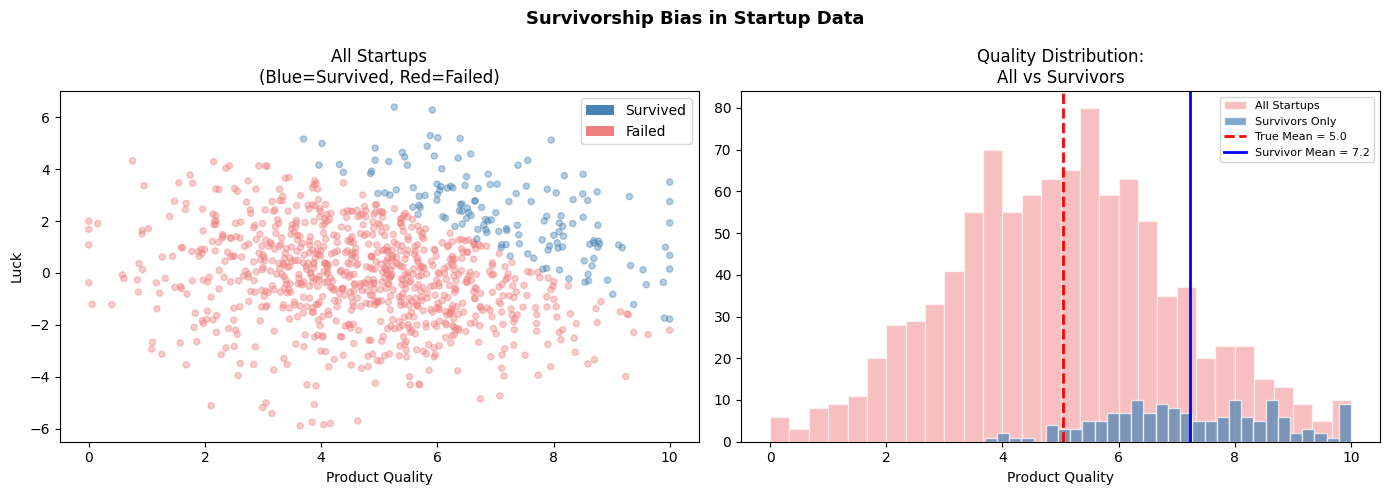

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)

# ─────────────────────────────────────────
# Simulate a startup ecosystem
# 1000 startups: only 150 "survived" (got funded/profitable)
# ─────────────────────────────────────────

n_startups = 1000
# True feature: quality of product (0-10)
product_quality = np.random.normal(loc=5, scale=2, size=n_startups).clip(0, 10)

# True feature: market timing luck (random!)
luck = np.random.normal(loc=0, scale=2, size=n_startups)

# Survival depends on BOTH quality and luck
survival_score = product_quality + luck
survived = survival_score > np.percentile(survival_score, 85)  # Top 15% survive

df = pd.DataFrame({
    'product_quality': product_quality,
    'luck': luck,
    'survived': survived
})

print("=== Survivorship Bias Demonstration ===")
print(f"Total startups:     {n_startups}")
print(f"Survivors:          {survived.sum()}")
print(f"\nMean product quality (ALL startups):       {df['product_quality'].mean():.2f}")
print(f"Mean product quality (SURVIVORS only):     {df[df['survived']]['product_quality'].mean():.2f}")
print(f"\n⚠️  If you only study survivors, you think average quality needed is much higher!")
# ─────────────────────────────────────────
# Visualization: Who survived and why?
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Survivorship Bias in Startup Data', fontsize=13, fontweight='bold')

# Plot 1: Scatter — quality vs luck, colored by survival
colors = df['survived'].map({True: 'steelblue', False: 'lightcoral'})
axes[0].scatter(df['product_quality'], df['luck'],
                c=colors, alpha=0.4, s=20)
axes[0].set_xlabel('Product Quality')
axes[0].set_ylabel('Luck')
axes[0].set_title('All Startups\n(Blue=Survived, Red=Failed)')

# Add legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Survived'),
                   Patch(facecolor='lightcoral', label='Failed')]
axes[0].legend(handles=legend_elements)

# Plot 2: Quality distribution — all vs survivors
axes[1].hist(df['product_quality'], bins=30, alpha=0.5,
             color='lightcoral', label='All Startups', edgecolor='white')
axes[1].hist(df[df['survived']]['product_quality'], bins=30, alpha=0.7,
             color='steelblue', label='Survivors Only', edgecolor='white')
axes[1].axvline(df['product_quality'].mean(), color='red',
                linestyle='--', linewidth=2, label=f"True Mean = {df['product_quality'].mean():.1f}")
axes[1].axvline(df[df['survived']]['product_quality'].mean(), color='blue',
                linestyle='-', linewidth=2, label=f"Survivor Mean = {df[df['survived']]['product_quality'].mean():.1f}")
axes[1].set_xlabel('Product Quality')
axes[1].set_title('Quality Distribution:\nAll vs Survivors')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

=== Regression to the Mean ===
Overall mean — Exam 1: 70.1 | Exam 2: 69.7

TOP scorers (Exam1 > 90):
  Avg Exam 1: 93.5
  Avg Exam 2: 83.0  ← Dropped toward mean

LOW scorers (Exam1 < 50):
  Avg Exam 1: 45.1
  Avg Exam 2: 57.3  ← Rose toward mean


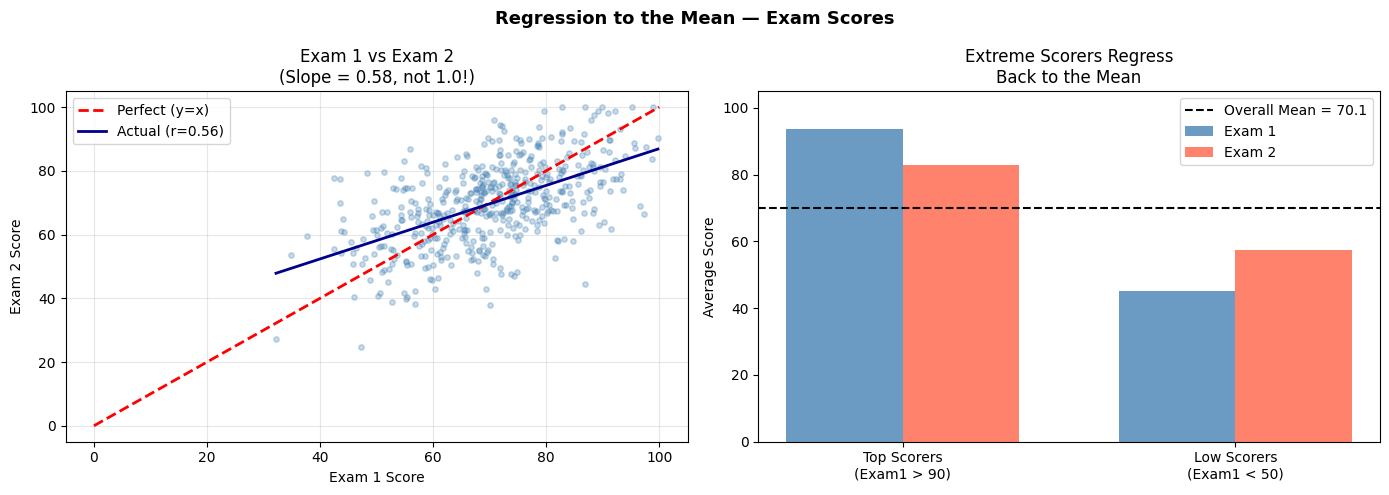

In [ ]:
# ─────────────────────────────────────────
# Simulate: Students take 2 exams
# True ability is fixed, but performance has noise
# ─────────────────────────────────────────

n_students = 500
true_ability = np.random.normal(loc=70, scale=10, size=n_students)  # True skill

# Exam scores = true ability + random noise (luck/day)
exam1 = true_ability + np.random.normal(0, 8, n_students)
exam2 = true_ability + np.random.normal(0, 8, n_students)

# Clip to realistic range
exam1 = np.clip(exam1, 0, 100)
exam2 = np.clip(exam2, 0, 100)

df_students = pd.DataFrame({'exam1': exam1, 'exam2': exam2})

# ─────────────────────────────────────────
# Key Analysis: Top scorers in Exam 1 —
# what do they score in Exam 2?
# ─────────────────────────────────────────
top_scorers = df_students[df_students['exam1'] > 90]
low_scorers = df_students[df_students['exam1'] < 50]

print("=== Regression to the Mean ===")
print(f"Overall mean — Exam 1: {exam1.mean():.1f} | Exam 2: {exam2.mean():.1f}")
print()
print(f"TOP scorers (Exam1 > 90):")
print(f"  Avg Exam 1: {top_scorers['exam1'].mean():.1f}")
print(f"  Avg Exam 2: {top_scorers['exam2'].mean():.1f}  ← Dropped toward mean")
print()
print(f"LOW scorers (Exam1 < 50):")
print(f"  Avg Exam 1: {low_scorers['exam1'].mean():.1f}")
print(f"  Avg Exam 2: {low_scorers['exam2'].mean():.1f}  ← Rose toward mean")
# ─────────────────────────────────────────
# Visualization: Regression to the Mean
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regression to the Mean — Exam Scores', fontsize=13, fontweight='bold')

# Plot 1: Scatter with regression line
axes[0].scatter(df_students['exam1'], df_students['exam2'],
                alpha=0.3, color='steelblue', s=15)

# Perfect prediction line (if no regression to mean)
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect (y=x)')

# Actual regression line
slope, intercept, r, p, se = stats.linregress(exam1, exam2)
x_line = np.array([exam1.min(), exam1.max()])
axes[0].plot(x_line, intercept + slope * x_line,
             'darkblue', linewidth=2, label=f'Actual (r={r:.2f})')
axes[0].set_xlabel('Exam 1 Score')
axes[0].set_ylabel('Exam 2 Score')
axes[0].set_title(f'Exam 1 vs Exam 2\n(Slope = {slope:.2f}, not 1.0!)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Top vs Low scorers — before and after
categories = ['Top Scorers\n(Exam1 > 90)', 'Low Scorers\n(Exam1 < 50)']
exam1_means = [top_scorers['exam1'].mean(), low_scorers['exam1'].mean()]
exam2_means = [top_scorers['exam2'].mean(), low_scorers['exam2'].mean()]

x = np.arange(len(categories))
width = 0.35
axes[1].bar(x - width/2, exam1_means, width, label='Exam 1',
            color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, exam2_means, width, label='Exam 2',
            color='tomato', alpha=0.8)
axes[1].axhline(exam1.mean(), color='black', linestyle='--',
                linewidth=1.5, label=f'Overall Mean = {exam1.mean():.1f}')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel('Average Score')
axes[1].set_title('Extreme Scorers Regress\nBack to the Mean')
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()


In [ ]:
# ─────────────────────────────────────────
# Population: App session times
# HEAVILY RIGHT-SKEWED (exponential)
# Most users: 1-3 min, some users: 30+ min
# ─────────────────────────────────────────
population_size = 100_000
population = np.random.exponential(scale=6, size=population_size)
true_mean = population.mean()
true_std = population.std()

print(f"Population — Mean: {true_mean:.2f} min | Std: {true_std:.2f} min")
print(f"Population Shape: Heavily Right-Skewed (not normal!)")
# ─────────────────────────────────────────
# Build Sampling Distributions for
# different sample sizes
# ─────────────────────────────────────────
sample_sizes = [5, 30, 100, 500]
n_simulations = 2000  # Draw 2000 samples for each size

sampling_distributions = {}

for n in sample_sizes:
    sample_means = []
    for _ in range(n_simulations):
        sample = np.random.choice(population, size=n, replace=False)
        sample_means.append(sample.mean())
    sampling_distributions[n] = np.array(sample_means)


Population — Mean: 5.98 min | Std: 5.96 min
Population Shape: Heavily Right-Skewed (not normal!)


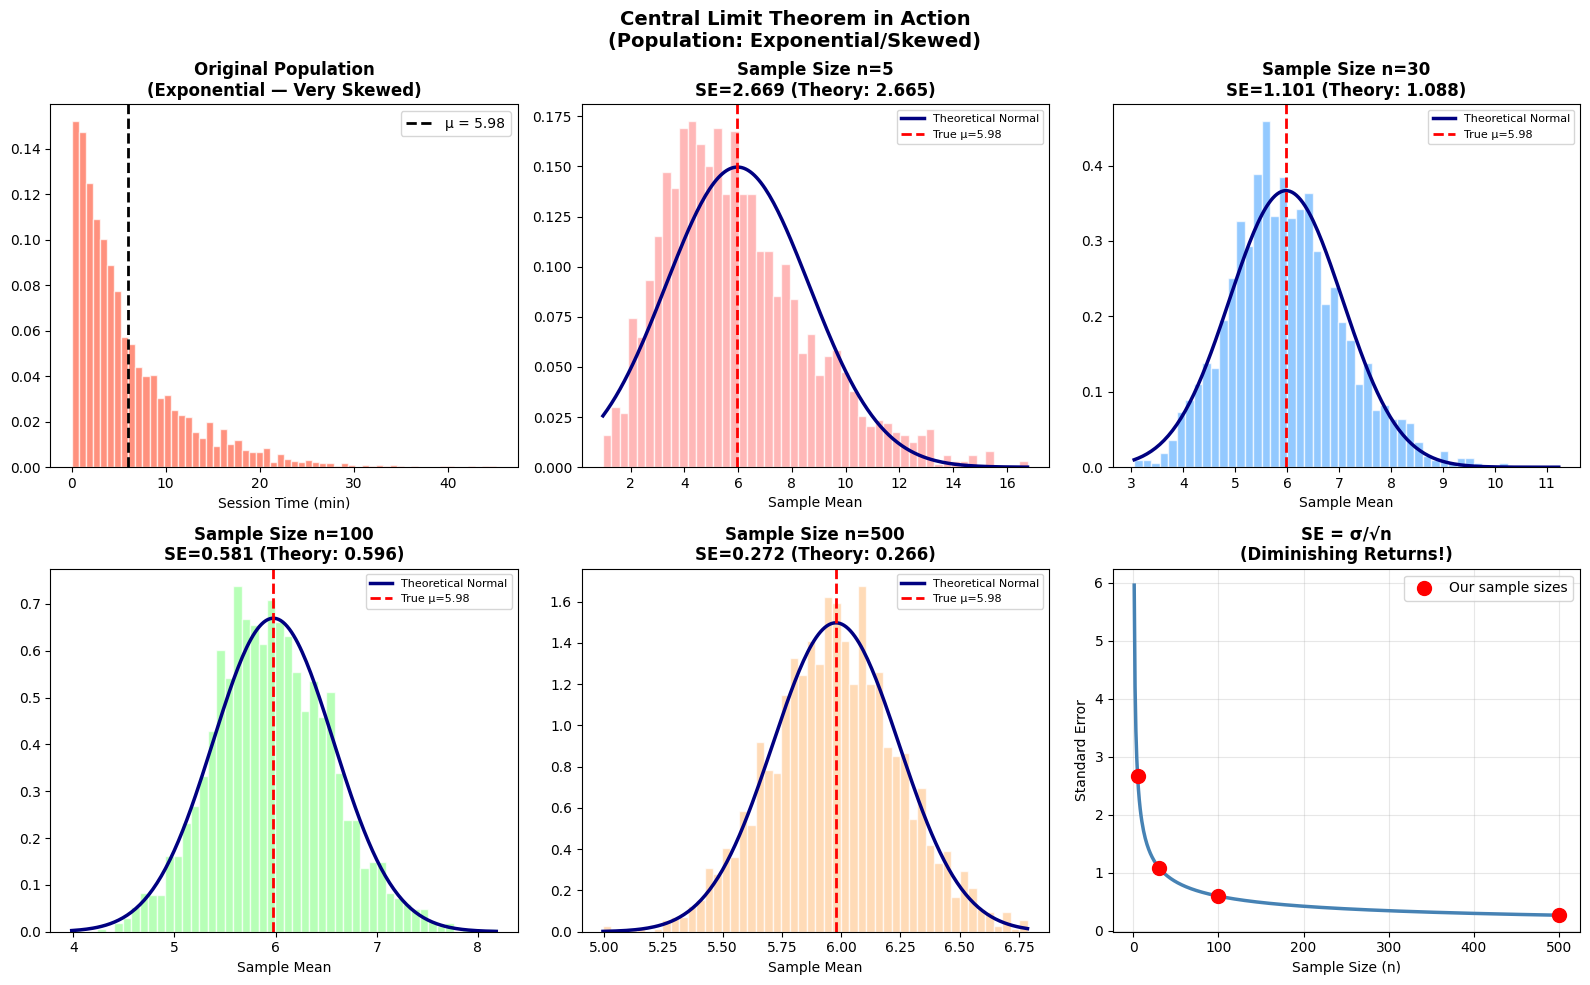

=== Your Sample Statistics ===
Sample Size (n):    100
Sample Mean (x̄):   6.422 min
Sample Std (s):     6.826 min
Standard Error:     0.683 min

True Population Mean: 5.978 min
Your estimate is off by: 0.445 min

Interpretation: Your sample mean typically varies
±0.683 min from the true population mean


/tmp/ipykernel_24215/1863886368.py:102: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


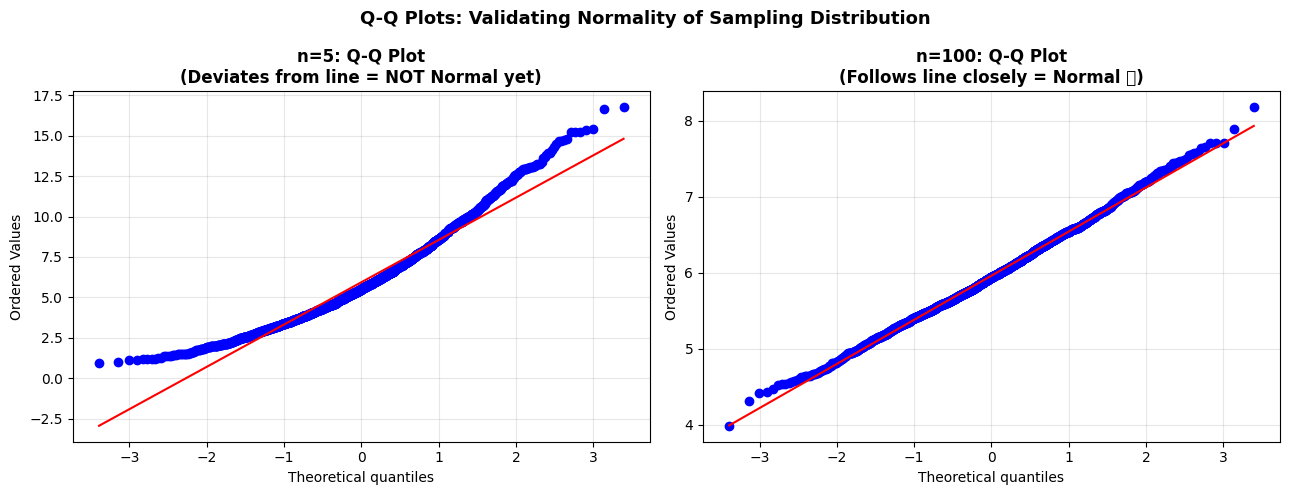

In [ ]:
# ─────────────────────────────────────────
# Visualization: CLT in Action
# ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Central Limit Theorem in Action\n(Population: Exponential/Skewed)',
             fontsize=14, fontweight='bold')

# Plot 0: Original Population
axes[0, 0].hist(population[:3000], bins=60, color='tomato',
                alpha=0.7, edgecolor='white', density=True)
axes[0, 0].axvline(true_mean, color='black', linestyle='--',
                   linewidth=2, label=f'μ = {true_mean:.2f}')
axes[0, 0].set_title('Original Population\n(Exponential — Very Skewed)',
                      fontweight='bold')
axes[0, 0].set_xlabel('Session Time (min)')
axes[0, 0].legend()

# Plot 1-4: Sampling distributions for each n
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
positions = [(0,1), (0,2), (1,0), (1,1)]

for idx, n in enumerate(sample_sizes):
    row, col = positions[idx]
    dist = sampling_distributions[n]
    se_theoretical = true_std / np.sqrt(n)
    se_actual = dist.std()

    axes[row, col].hist(dist, bins=50, color=colors[idx],
                        alpha=0.7, edgecolor='white', density=True)

    # Overlay theoretical normal curve
    x = np.linspace(dist.min(), dist.max(), 200)
    normal_curve = stats.norm.pdf(x, true_mean, se_theoretical)
    axes[row, col].plot(x, normal_curve, 'navy', linewidth=2.5,
                        label='Theoretical Normal')
    axes[row, col].axvline(true_mean, color='red', linestyle='--',
                           linewidth=2, label=f'True μ={true_mean:.2f}')
    axes[row, col].set_title(f'Sample Size n={n}\nSE={se_actual:.3f} '
                              f'(Theory: {se_theoretical:.3f})',
                              fontweight='bold')
    axes[row, col].set_xlabel('Sample Mean')
    axes[row, col].legend(fontsize=8)

# Plot 5: SE vs Sample Size
ns = np.arange(1, 501)
ses = true_std / np.sqrt(ns)
axes[1, 2].plot(ns, ses, color='steelblue', linewidth=2.5)
axes[1, 2].scatter(sample_sizes,
                   [true_std/np.sqrt(n) for n in sample_sizes],
                   color='red', s=100, zorder=5, label='Our sample sizes')
axes[1, 2].set_xlabel('Sample Size (n)')
axes[1, 2].set_ylabel('Standard Error')
axes[1, 2].set_title('SE = σ/√n\n(Diminishing Returns!)', fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# ─────────────────────────────────────────
# Real DS Scenario:
# You collect ONE sample of app users.
# Estimate the true mean session time
# and quantify your uncertainty.
# ─────────────────────────────────────────

my_sample = np.random.choice(population, size=100, replace=False)

sample_mean = my_sample.mean()
sample_std  = my_sample.std(ddof=1)        # ddof=1 → unbiased estimate
standard_error = sample_std / np.sqrt(len(my_sample))

print("=== Your Sample Statistics ===")
print(f"Sample Size (n):    {len(my_sample)}")
print(f"Sample Mean (x̄):   {sample_mean:.3f} min")
print(f"Sample Std (s):     {sample_std:.3f} min")
print(f"Standard Error:     {standard_error:.3f} min")
print(f"\nTrue Population Mean: {true_mean:.3f} min")
print(f"Your estimate is off by: {abs(sample_mean - true_mean):.3f} min")
print(f"\nInterpretation: Your sample mean typically varies")
print(f"±{standard_error:.3f} min from the true population mean")

# ─────────────────────────────────────────
# Q-Q Plot: Is your sampling distribution
# actually Normal? (Validating CLT)
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Q-Q Plots: Validating Normality of Sampling Distribution',
             fontsize=13, fontweight='bold')

# Q-Q for small n (n=5) — NOT normal yet
stats.probplot(sampling_distributions[5], dist="norm", plot=axes[0])
axes[0].set_title('n=5: Q-Q Plot\n(Deviates from line = NOT Normal yet)',
                   fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Q-Q for large n (n=100) — Normal!
stats.probplot(sampling_distributions[100], dist="norm", plot=axes[1])
axes[1].set_title('n=100: Q-Q Plot\n(Follows line closely = Normal ✅)',
                   fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

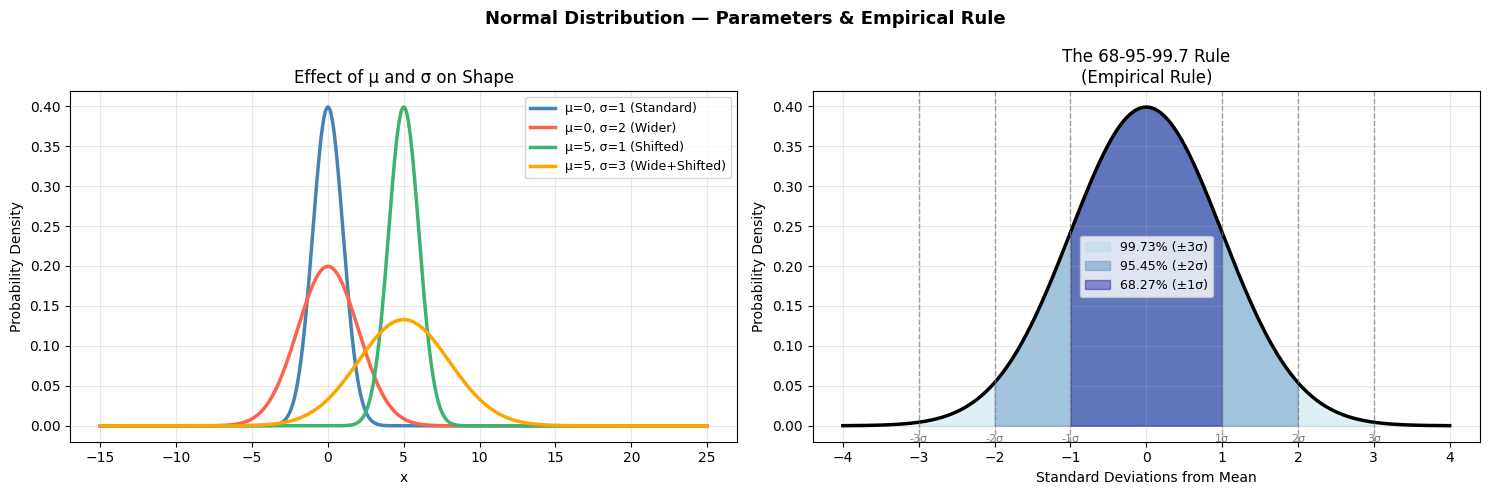

In [ ]:
# ─────────────────────────────────────────
# Visualize Normal distributions with
# different μ and σ parameters
# ─────────────────────────────────────────
x = np.linspace(-15, 25, 1000)

distributions = [
    {'mu': 0,  'sigma': 1,  'color': 'steelblue',    'label': 'μ=0, σ=1 (Standard)'},
    {'mu': 0,  'sigma': 2,  'color': 'tomato',        'label': 'μ=0, σ=2 (Wider)'},
    {'mu': 5,  'sigma': 1,  'color': 'mediumseagreen','label': 'μ=5, σ=1 (Shifted)'},
    {'mu': 5,  'sigma': 3,  'color': 'orange',        'label': 'μ=5, σ=3 (Wide+Shifted)'},
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Normal Distribution — Parameters & Empirical Rule',
             fontsize=13, fontweight='bold')

# Plot 1: Effect of μ and σ
for d in distributions:
    pdf = stats.norm.pdf(x, d['mu'], d['sigma'])
    axes[0].plot(x, pdf, color=d['color'],
                 linewidth=2.5, label=d['label'])

axes[0].set_title('Effect of μ and σ on Shape')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Probability Density')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2: 68-95-99.7 Rule
mu, sigma = 0, 1
x2 = np.linspace(-4, 4, 1000)
pdf2 = stats.norm.pdf(x2, mu, sigma)

axes[1].plot(x2, pdf2, 'black', linewidth=2.5)

# Fill regions
fills = [
    ([-3, 3],   'lightblue',  '99.73% (±3σ)'),
    ([-2, 2],   'steelblue',  '95.45% (±2σ)'),
    ([-1, 1],   'darkblue',   '68.27% (±1σ)'),
]

for (bounds, color, label) in fills:
    mask = (x2 >= bounds[0]) & (x2 <= bounds[1])
    axes[1].fill_between(x2[mask], pdf2[mask],
                          alpha=0.4, color=color, label=label)

for s in [-3, -2, -1, 1, 2, 3]:
    axes[1].axvline(s, color='gray', linestyle='--',
                    linewidth=1, alpha=0.7)
    axes[1].text(s, -0.02, f'{s}σ', ha='center',
                 fontsize=8, color='gray')

axes[1].set_title('The 68-95-99.7 Rule\n(Empirical Rule)')
axes[1].set_xlabel('Standard Deviations from Mean')
axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────
# DS Use Case: Detect anomalous API
# response times using Z-scores
# ─────────────────────────────────────────

# Simulate API response times (ms)
# Mostly normal, with a few anomalies
normal_times  = np.random.normal(loc=200, scale=30, size=950)
anomaly_times = np.random.normal(loc=400, scale=20, size=50)
response_times = np.concatenate([normal_times, anomaly_times])
np.random.shuffle(response_times)

# Calculate Z-scores
mu_rt    = response_times.mean()
sigma_rt = response_times.std()
z_scores = (response_times - mu_rt) / sigma_rt

# Flag anomalies: |Z| > 3
anomalies = np.abs(z_scores) > 3

print("=== Z-Score Anomaly Detection ===")
print(f"Total observations:  {len(response_times)}")
print(f"Mean response time:  {mu_rt:.1f} ms")
print(f"Std response time:   {sigma_rt:.1f} ms")
print(f"Anomalies detected:  {anomalies.sum()}")
print(f"Anomaly rate:        {anomalies.mean()*100:.1f}%")
print(f"\nZ-score threshold:   ±3σ")
print(f"Response time threshold: {mu_rt + 3*sigma_rt:.1f} ms")

# Show top anomalies
top_anomaly_idx = np.argsort(np.abs(z_scores))[-5:][::-1]
print(f"\nTop 5 Anomalies:")
print(f"{'Response Time':>15} | {'Z-Score':>8}")
print("─" * 28)
for idx in top_anomaly_idx:
    print(f"{response_times[idx]:>15.1f} ms | {z_scores[idx]:>8.2f}")

=== Z-Score Anomaly Detection ===
Total observations:  1000
Mean response time:  209.8 ms
Std response time:   51.2 ms
Anomalies detected:  48
Anomaly rate:        4.8%

Z-score threshold:   ±3σ
Response time threshold: 363.4 ms

Top 5 Anomalies:
  Response Time |  Z-Score
────────────────────────────
          431.8 ms |     4.34
          431.1 ms |     4.32
          429.7 ms |     4.30
          428.7 ms |     4.28
          424.4 ms |     4.19


/tmp/ipykernel_24215/3150861645.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24215/3150861645.py:44: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


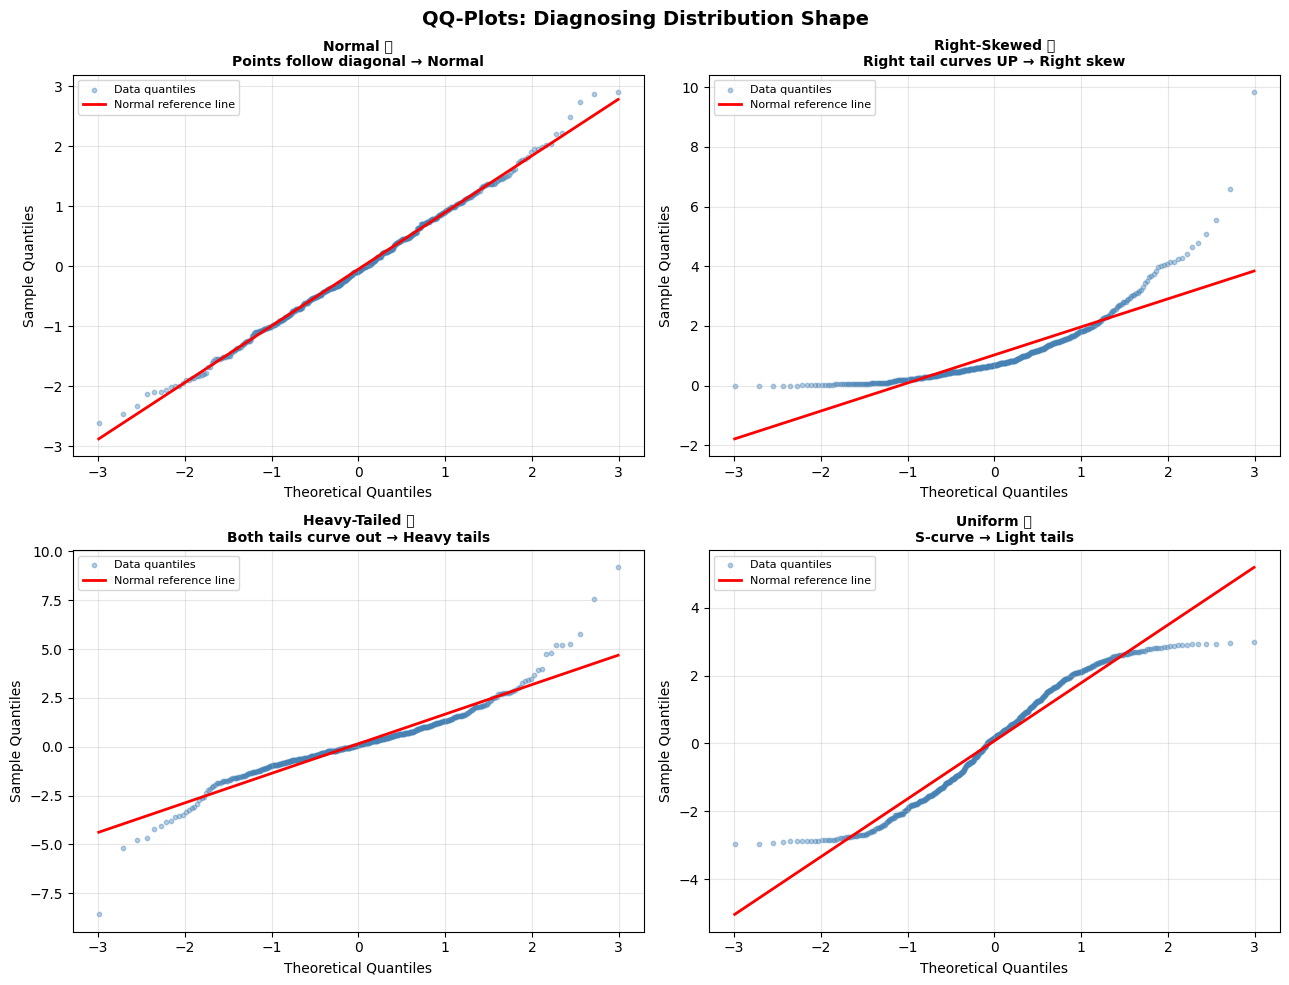

In [ ]:
# ─────────────────────────────────────────
# Compare QQ-plots for 4 different
# data types — see what each looks like
# ─────────────────────────────────────────
n = 500

datasets = {
    'Normal ✅':         np.random.normal(0, 1, n),
    'Right-Skewed ❌':   np.random.exponential(1, n),
    'Heavy-Tailed ❌':   np.random.standard_t(df=3, size=n),
    'Uniform ❌':        np.random.uniform(-3, 3, n),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('QQ-Plots: Diagnosing Distribution Shape',
             fontsize=14, fontweight='bold')

interpretations = {
    'Normal ✅':       'Points follow diagonal → Normal',
    'Right-Skewed ❌': 'Right tail curves UP → Right skew',
    'Heavy-Tailed ❌': 'Both tails curve out → Heavy tails',
    'Uniform ❌':      'S-curve → Light tails',
}

for ax, (name, data) in zip(axes.flatten(), datasets.items()):
    # QQ plot
    (osm, osr), (slope, intercept, r) = stats.probplot(data,
                                                         dist='norm')
    ax.scatter(osm, osr, alpha=0.4, color='steelblue',
               s=10, label='Data quantiles')

    # Reference line
    x_line = np.array([osm.min(), osm.max()])
    ax.plot(x_line, slope * x_line + intercept,
            'red', linewidth=2, label='Normal reference line')

    ax.set_title(f'{name}\n{interpretations[name]}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_24215/1495936082.py:40: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24215/1495936082.py:40: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


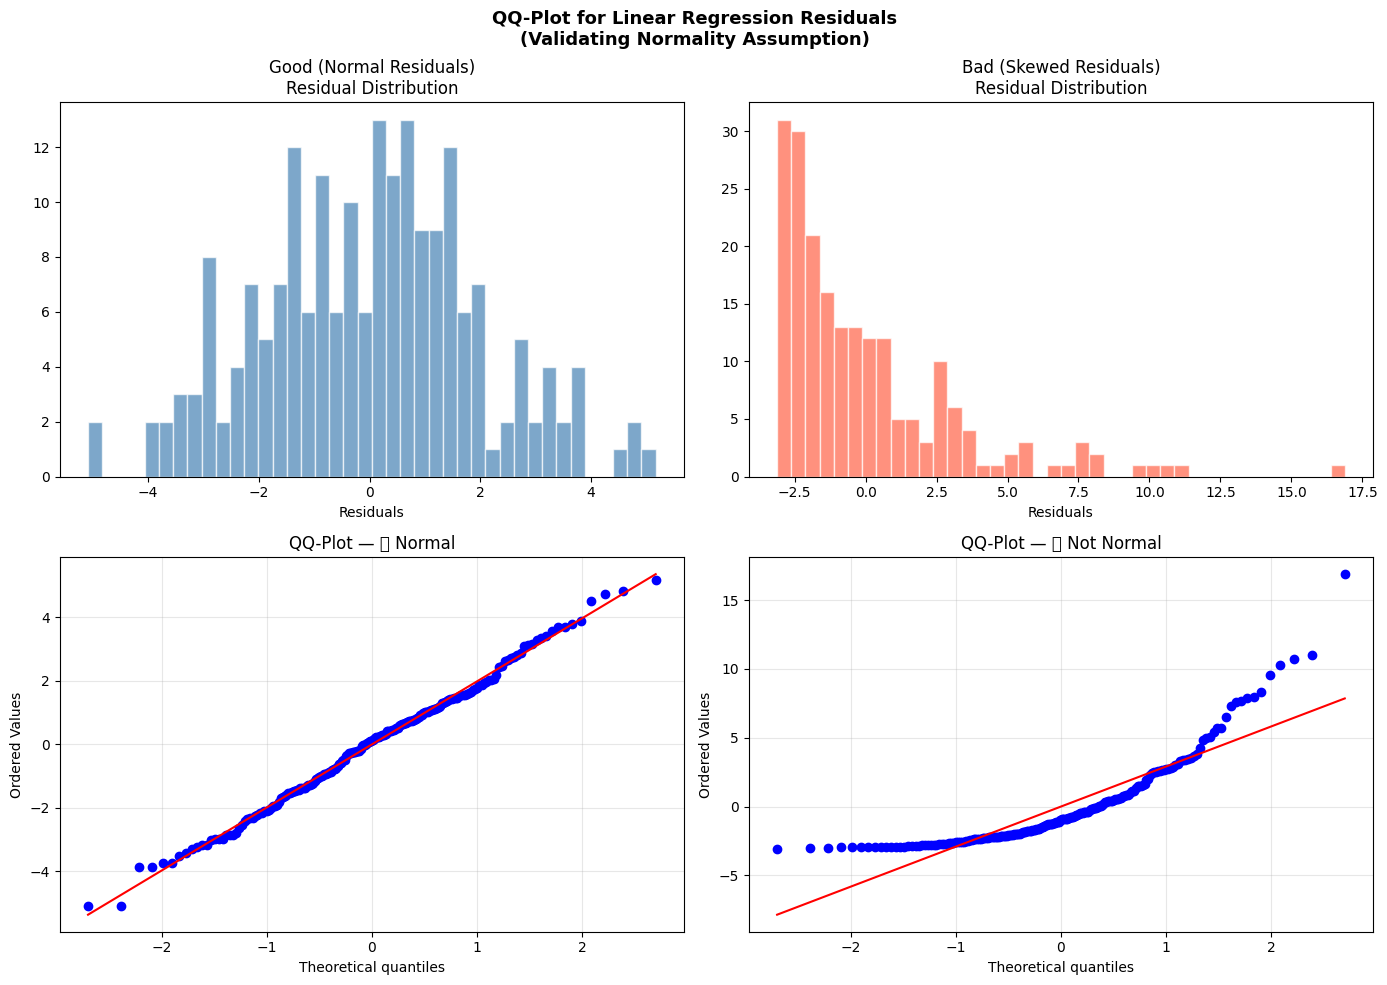

=== Normality Tests on Residuals ===
Good model     : Shapiro-Wilk p=0.5782 → Normal ✅
Bad model      : Shapiro-Wilk p=0.0000 → NOT Normal ❌


In [ ]:
# ─────────────────────────────────────────
# Critical ML Use Case:
# Linear Regression assumes residuals
# are normally distributed.
# QQ-plot validates this assumption.
# ─────────────────────────────────────────
from sklearn.linear_model import LinearRegression

# Generate data
X      = np.random.uniform(0, 10, 200).reshape(-1, 1)
y_good = 3 * X.flatten() + np.random.normal(0, 2, 200)
y_bad  = 3 * X.flatten() + np.random.exponential(3, 200)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('QQ-Plot for Linear Regression Residuals\n'
             '(Validating Normality Assumption)',
             fontsize=13, fontweight='bold')

for col, (y, label) in enumerate(
        [(y_good, 'Good (Normal Residuals)'),
         (y_bad,  'Bad (Skewed Residuals)')]):

    model = LinearRegression().fit(X, y)
    residuals = y - model.predict(X)

    # Residual histogram
    axes[0, col].hist(residuals, bins=40,
                      color='steelblue' if col==0 else 'tomato',
                      alpha=0.7, edgecolor='white')
    axes[0, col].set_title(f'{label}\nResidual Distribution')
    axes[0, col].set_xlabel('Residuals')

    # QQ-plot of residuals
    stats.probplot(residuals, dist='norm',
                   plot=axes[1, col])
    axes[1, col].set_title(
        f'QQ-Plot — {"✅ Normal" if col==0 else "❌ Not Normal"}')
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=== Normality Tests on Residuals ===")
for y, label in [(y_good, 'Good model'),
                  (y_bad,  'Bad model')]:
    model     = LinearRegression().fit(X, y)
    residuals = y - model.predict(X)
    stat, p   = stats.shapiro(residuals[:50])
    result    = "Normal ✅" if p > 0.05 else "NOT Normal ❌"
    print(f"{label:15}: Shapiro-Wilk p={p:.4f} → {result}")

=== Customer Revenue Statistics ===
Mean Revenue:    ₹    306.47
Median Revenue:  ₹    150.31
Mean/Median:            2.04x apart
Max Revenue:     ₹  21531.73

Skewness:  11.138  (0=normal, >1=heavily skewed)
Kurtosis:  260.996 (0=normal, >0=heavy tails)


/tmp/ipykernel_24215/815049506.py:70: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24215/815049506.py:70: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


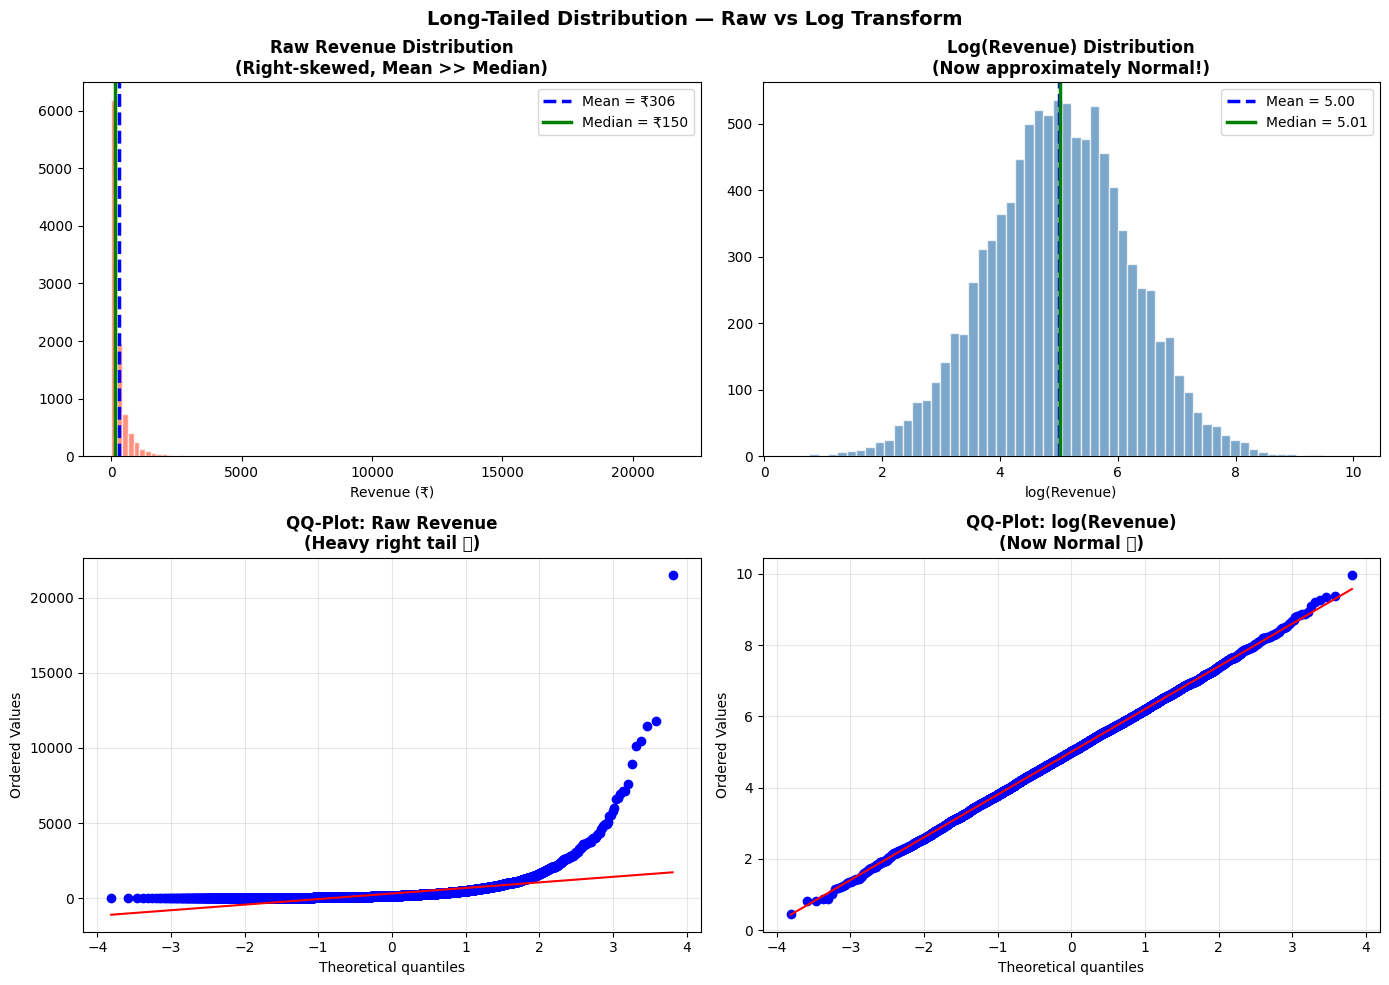

=== Pareto Analysis (80/20 Rule) ===
    Top X% Customers |    % of Revenue
────────────────────────────────────────
                  1% |           13.6%
                  5% |           33.1%
                 10% |           46.9%
                 20% |           63.9%


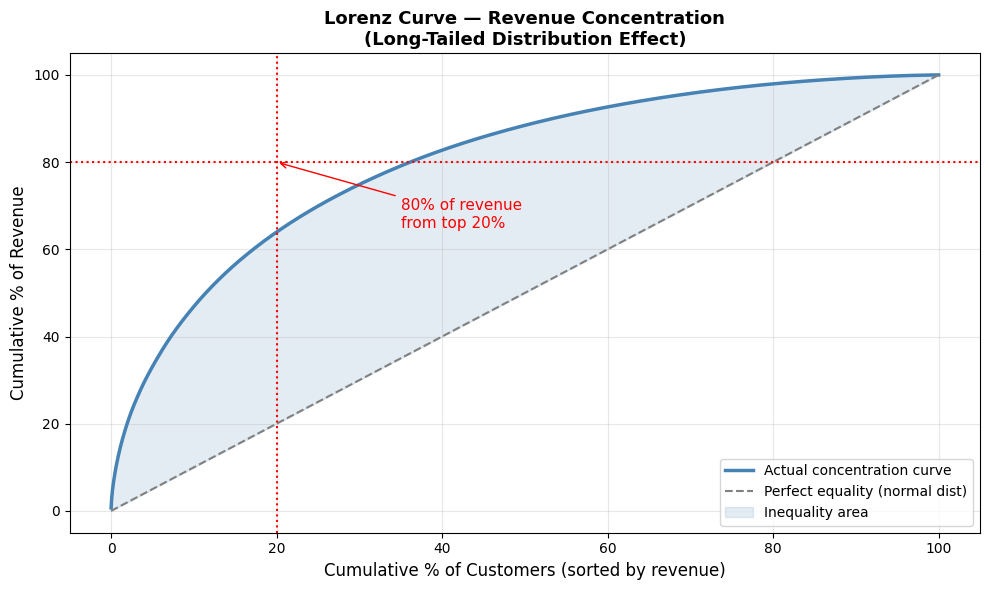

=== Model Performance: Raw vs Log Transform ===

Metric                         Raw Target   Log Transform
─────────────────────────────────────────────────────────
MAE (₹)                           2189.95         1435.28
R² Score                           0.2671          0.4337

✅ Log transform almost always wins on skewed targets


In [ ]:
# ─────────────────────────────────────────
# Simulate e-commerce customer revenue
# Classic long-tailed distribution
# ─────────────────────────────────────────
n_customers = 10_000

# Log-normal revenue distribution
# Most customers: low spend, few: very high
revenue = np.random.lognormal(mean=5, sigma=1.2,
                               size=n_customers)

mean_rev   = revenue.mean()
median_rev = np.median(revenue)

print("=== Customer Revenue Statistics ===")
print(f"Mean Revenue:    ₹{mean_rev:>10.2f}")
print(f"Median Revenue:  ₹{median_rev:>10.2f}")
print(f"Mean/Median:      {mean_rev/median_rev:>10.2f}x apart")
print(f"Max Revenue:     ₹{revenue.max():>10.2f}")
print(f"\nSkewness:  {stats.skew(revenue):.3f}  (0=normal, >1=heavily skewed)")
print(f"Kurtosis:  {stats.kurtosis(revenue):.3f} (0=normal, >0=heavy tails)")
# ─────────────────────────────────────────
# The Power of Log Transform
# ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Long-Tailed Distribution — Raw vs Log Transform',
             fontsize=14, fontweight='bold')

# Plot 1: Raw distribution
axes[0,0].hist(revenue, bins=100, color='tomato',
               alpha=0.7, edgecolor='white')
axes[0,0].axvline(mean_rev, color='blue', linewidth=2.5,
                   linestyle='--',
                   label=f'Mean = ₹{mean_rev:.0f}')
axes[0,0].axvline(median_rev, color='green', linewidth=2.5,
                   linestyle='-',
                   label=f'Median = ₹{median_rev:.0f}')
axes[0,0].set_title('Raw Revenue Distribution\n(Right-skewed, Mean >> Median)',
                     fontweight='bold')
axes[0,0].set_xlabel('Revenue (₹)')
axes[0,0].legend()

# Plot 2: Log-transformed
log_revenue = np.log(revenue)
axes[0,1].hist(log_revenue, bins=60, color='steelblue',
               alpha=0.7, edgecolor='white')
axes[0,1].axvline(log_revenue.mean(), color='blue',
                   linewidth=2.5, linestyle='--',
                   label=f'Mean = {log_revenue.mean():.2f}')
axes[0,1].axvline(np.median(log_revenue), color='green',
                   linewidth=2.5, linestyle='-',
                   label=f'Median = {np.median(log_revenue):.2f}')
axes[0,1].set_title('Log(Revenue) Distribution\n(Now approximately Normal!)',
                     fontweight='bold')
axes[0,1].set_xlabel('log(Revenue)')
axes[0,1].legend()

# Plot 3: QQ-plot of raw
stats.probplot(revenue, dist='norm', plot=axes[1,0])
axes[1,0].set_title('QQ-Plot: Raw Revenue\n(Heavy right tail ❌)',
                     fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# Plot 4: QQ-plot of log
stats.probplot(log_revenue, dist='norm', plot=axes[1,1])
axes[1,1].set_title('QQ-Plot: log(Revenue)\n(Now Normal ✅)',
                     fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# Measure Pareto concentration:
# What % of customers drive what % of revenue?
# ─────────────────────────────────────────
revenue_sorted = np.sort(revenue)[::-1]
cumulative_rev = np.cumsum(revenue_sorted) / revenue.sum()
cumulative_cust = np.arange(1, len(revenue)+1) / len(revenue)

# Find: top X% of customers = Y% of revenue
thresholds = [0.01, 0.05, 0.10, 0.20]
print("=== Pareto Analysis (80/20 Rule) ===")
print(f"{'Top X% Customers':>20} | {'% of Revenue':>15}")
print("─" * 40)
for t in thresholds:
    idx = int(t * n_customers)
    rev_share = revenue_sorted[:idx].sum() / revenue.sum()
    print(f"{t*100:>19.0f}% | {rev_share*100:>14.1f}%")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cumulative_cust * 100, cumulative_rev * 100,
        color='steelblue', linewidth=2.5,
        label='Actual concentration curve')
ax.plot([0, 100], [0, 100], 'gray', linestyle='--',
        linewidth=1.5, label='Perfect equality (normal dist)')

# Mark 80/20 point
ax.axhline(80, color='red', linestyle=':', linewidth=1.5)
ax.axvline(20, color='red', linestyle=':', linewidth=1.5)
ax.annotate('80% of revenue\nfrom top 20%',
            xy=(20, 80), xytext=(35, 65),
            fontsize=11, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.fill_between(cumulative_cust * 100,
                cumulative_rev * 100,
                cumulative_cust * 100,
                alpha=0.15, color='steelblue',
                label='Inequality area')
ax.set_xlabel('Cumulative % of Customers (sorted by revenue)',
              fontsize=12)
ax.set_ylabel('Cumulative % of Revenue', fontsize=12)
ax.set_title('Lorenz Curve — Revenue Concentration\n'
             '(Long-Tailed Distribution Effect)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# Show: Training a regression model on
# long-tailed target WITHOUT log transform
# vs WITH log transform
# ─────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Features: customer age, tenure, visits
np.random.seed(42)
n = 1000
age     = np.random.randint(18, 65, n)
tenure  = np.random.randint(1, 60, n)
visits  = np.random.randint(1, 100, n)

# Revenue: log-normally related to features
log_rev = 3 + 0.02*age + 0.05*tenure + 0.03*visits \
          + np.random.normal(0, 0.8, n)
revenue_target = np.exp(log_rev)

X = np.column_stack([age, tenure, visits])
X_tr, X_te, y_tr, y_te = train_test_split(
    X, revenue_target, test_size=0.2, random_state=42)

# Model 1: Raw target
m1 = LinearRegression().fit(X_tr, y_tr)
pred1 = m1.predict(X_te)

# Model 2: Log-transformed target
m2 = LinearRegression().fit(X_tr, np.log(y_tr))
pred2 = np.exp(m2.predict(X_te))

print("=== Model Performance: Raw vs Log Transform ===")
print(f"\n{'Metric':<25} {'Raw Target':>15} {'Log Transform':>15}")
print("─" * 57)
print(f"{'MAE (₹)':<25} {mean_absolute_error(y_te,pred1):>15.2f} "
      f"{mean_absolute_error(y_te,pred2):>15.2f}")
print(f"{'R² Score':<25} {r2_score(y_te,pred1):>15.4f} "
      f"{r2_score(y_te,pred2):>15.4f}")
print(f"\n✅ Log transform almost always wins on skewed targets")

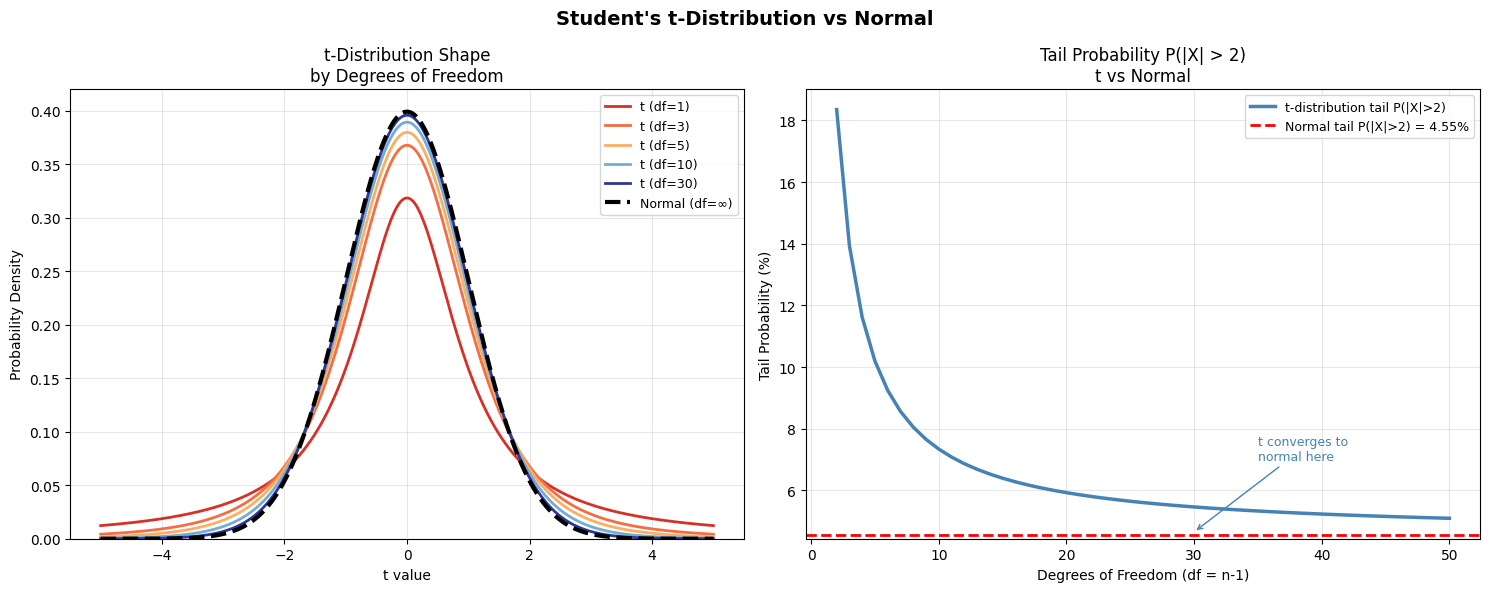

=== Coverage: t-CI vs Z-CI (target = 95%) ===
    n |  t* value |  t-CI coverage |  z-CI coverage
────────────────────────────────────────────────────
    5 |     2.776 |          95.1% |          87.5%
   10 |     2.262 |          94.8% |          91.6%
   15 |     2.145 |          94.9% |          92.7%
   20 |     2.093 |          95.0% |          93.5%
   30 |     2.045 |          95.5% |          94.5%
   50 |     2.010 |          95.5% |          95.0%
  100 |     1.984 |          94.3% |          94.1%


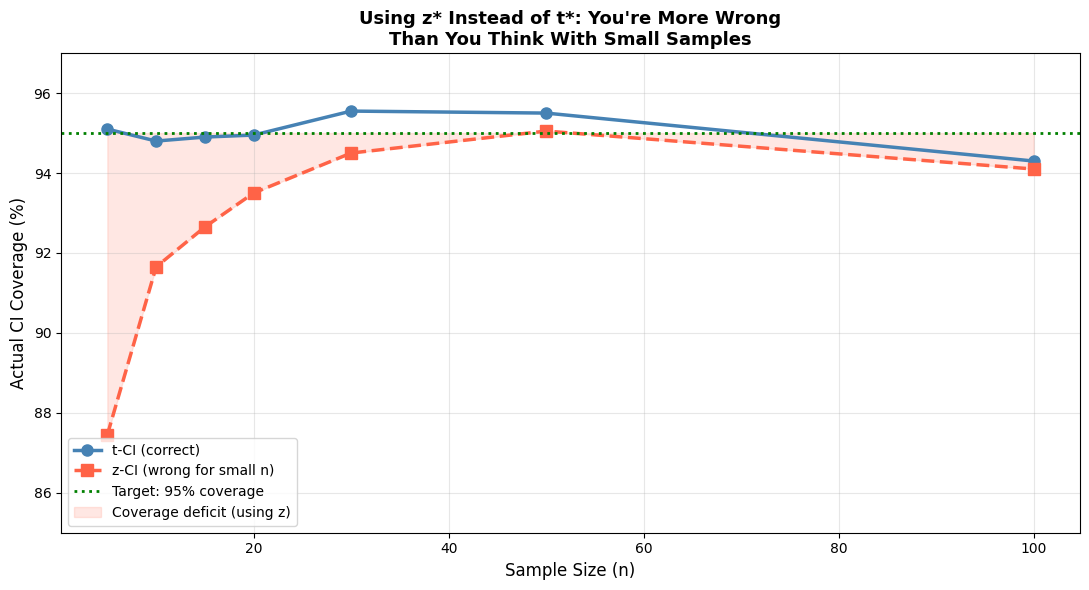

In [ ]:
# ─────────────────────────────────────────
# Compare t-distributions with different df
# against the standard normal
# ─────────────────────────────────────────
x = np.linspace(-5, 5, 1000)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Student's t-Distribution vs Normal",
             fontsize=14, fontweight='bold')

# Plot 1: Shape comparison
dfs     = [1, 3, 5, 10, 30]
colors  = ['#d73027','#f46d43','#fdae61','#74add1','#313695']

for df, color in zip(dfs, colors):
    pdf = stats.t.pdf(x, df=df)
    axes[0].plot(x, pdf, color=color, linewidth=2,
                 label=f't (df={df})')

# Normal
axes[0].plot(x, stats.norm.pdf(x), 'black',
             linewidth=3, linestyle='--',
             label='Normal (df=∞)')
axes[0].set_title('t-Distribution Shape\nby Degrees of Freedom')
axes[0].set_xlabel('t value')
axes[0].set_ylabel('Probability Density')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 0.42)
axes[0].grid(True, alpha=0.3)

# Plot 2: Tail probability comparison
# Show how much MORE probability is in tails for t vs normal
tail_probs_t      = []
tail_probs_normal = []
df_range = range(2, 51)

for df in df_range:
    # P(|X| > 2) — probability beyond ±2
    t_tail = 2 * stats.t.sf(2, df=df)
    n_tail = 2 * stats.norm.sf(2)
    tail_probs_t.append(t_tail * 100)
    tail_probs_normal.append(n_tail * 100)

axes[1].plot(list(df_range), tail_probs_t,
             'steelblue', linewidth=2.5,
             label='t-distribution tail P(|X|>2)')
axes[1].axhline(tail_probs_normal[0], color='red',
                linestyle='--', linewidth=2,
                label=f'Normal tail P(|X|>2) = {tail_probs_normal[0]:.2f}%')
axes[1].set_title('Tail Probability P(|X| > 2)\nt vs Normal')
axes[1].set_xlabel('Degrees of Freedom (df = n-1)')
axes[1].set_ylabel('Tail Probability (%)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].annotate('t converges to\nnormal here',
                 xy=(30, tail_probs_normal[0]+0.1),
                 xytext=(35, 7),
                 fontsize=9, color='steelblue',
                 arrowprops=dict(arrowstyle='->',
                                 color='steelblue'))

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# Show concretely: what happens if you use
# z* instead of t* for small samples?
# → Your CI is too narrow → overconfident
# ─────────────────────────────────────────

population = np.random.normal(loc=50, scale=10,
                               size=100_000)
true_mean  = population.mean()

sample_sizes  = [5, 10, 15, 20, 30, 50, 100]
t_coverage    = []   # % of CIs that capture true mean using t
z_coverage    = []   # % of CIs that capture true mean using z
n_experiments = 2000

for n in sample_sizes:
    t_captured = 0
    z_captured = 0

    for _ in range(n_experiments):
        samp = np.random.choice(population,
                                size=n, replace=False)
        xbar = samp.mean()
        se   = samp.std(ddof=1) / np.sqrt(n)

        # t-based CI (correct)
        t_star  = stats.t.ppf(0.975, df=n-1)
        t_lo    = xbar - t_star * se
        t_hi    = xbar + t_star * se

        # z-based CI (wrong for small n)
        z_star  = 1.96
        z_lo    = xbar - z_star * se
        z_hi    = xbar + z_star * se

        if t_lo <= true_mean <= t_hi:
            t_captured += 1
        if z_lo <= true_mean <= z_hi:
            z_captured += 1

    t_coverage.append(t_captured / n_experiments * 100)
    z_coverage.append(z_captured / n_experiments * 100)

# Results table
print("=== Coverage: t-CI vs Z-CI (target = 95%) ===")
print(f"{'n':>5} | {'t* value':>9} | "
      f"{'t-CI coverage':>14} | {'z-CI coverage':>14}")
print("─" * 52)
for i, n in enumerate(sample_sizes):
    t_star = stats.t.ppf(0.975, df=n-1)
    print(f"{n:>5} | {t_star:>9.3f} | "
          f"{t_coverage[i]:>13.1f}% | "
          f"{z_coverage[i]:>13.1f}%")


# Visualization
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(sample_sizes, t_coverage, 'o-',
        color='steelblue', linewidth=2.5,
        markersize=8, label='t-CI (correct)')
ax.plot(sample_sizes, z_coverage, 's--',
        color='tomato', linewidth=2.5,
        markersize=8, label='z-CI (wrong for small n)')
ax.axhline(95, color='green', linestyle=':',
           linewidth=2, label='Target: 95% coverage')

ax.fill_between(sample_sizes,
                [95]*len(sample_sizes), z_coverage,
                alpha=0.15, color='tomato',
                label='Coverage deficit (using z)')

ax.set_xlabel('Sample Size (n)', fontsize=12)
ax.set_ylabel('Actual CI Coverage (%)', fontsize=12)
ax.set_title("Using z* Instead of t*: You're More Wrong\n"
             "Than You Think With Small Samples",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(85, 97)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


           sum   mean  count
group                       
control     46  0.046   1000
treatment   74  0.074   1000

Absolute lift: 0.0280


/tmp/ipykernel_24215/1805066594.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='group', y='conversion_rate',


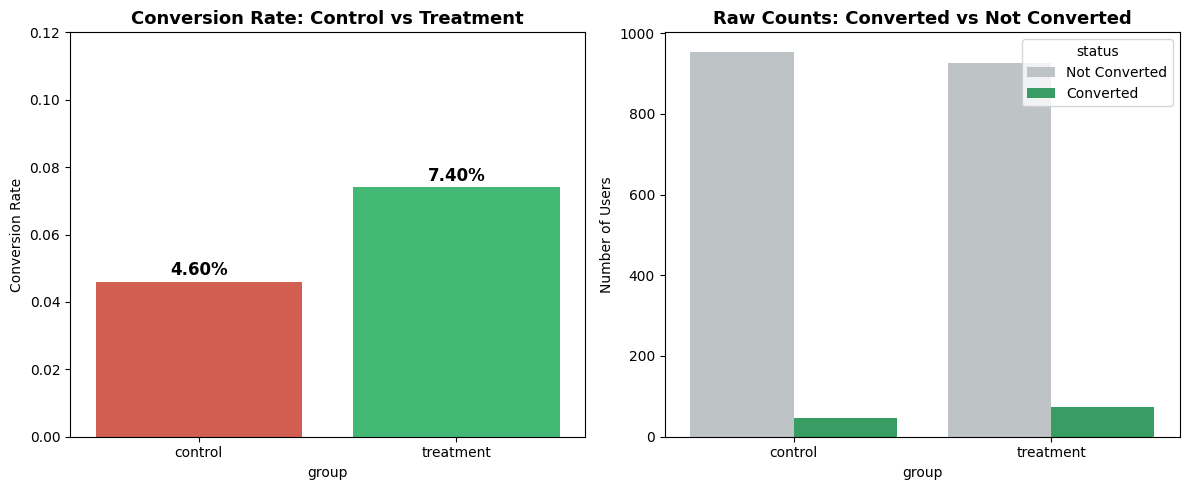

Chart saved.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Simulate A/B test data
n_users = 1000

# Control group: 5% conversion rate
control_conversions = np.random.binomial(n=1, p=0.05, size=n_users)

# Treatment group: 6.5% conversion rate
treatment_conversions = np.random.binomial(n=1, p=0.065, size=n_users)

# Build DataFrame
df = pd.DataFrame({
    'group': ['control'] * n_users + ['treatment'] * n_users,
    'converted': np.concatenate([control_conversions, treatment_conversions])
})

print(df.groupby('group')['converted'].agg(['sum', 'mean', 'count']))
print(f"\nAbsolute lift: {df[df.group=='treatment']['converted'].mean() - df[df.group=='control']['converted'].mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Conversion rate comparison
summary = df.groupby('group')['converted'].mean().reset_index()
summary.columns = ['group', 'conversion_rate']

sns.barplot(data=summary, x='group', y='conversion_rate',
            palette=['#E74C3C', '#2ECC71'], ax=axes[0])
axes[0].set_title('Conversion Rate: Control vs Treatment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_ylim(0, 0.12)

for i, row in summary.iterrows():
    axes[0].text(i, row['conversion_rate'] + 0.002,
                 f"{row['conversion_rate']:.2%}",
                 ha='center', fontweight='bold', fontsize=12)

# Plot 2: Raw counts — converted vs not
count_data = df.groupby(['group', 'converted']).size().reset_index(name='count')
count_data['status'] = count_data['converted'].map({0: 'Not Converted', 1: 'Converted'})

sns.barplot(data=count_data, x='group', y='count', hue='status',
            palette=['#BDC3C7', '#27AE60'], ax=axes[1])
axes[1].set_title('Raw Counts: Converted vs Not Converted', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.savefig('ab_test_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

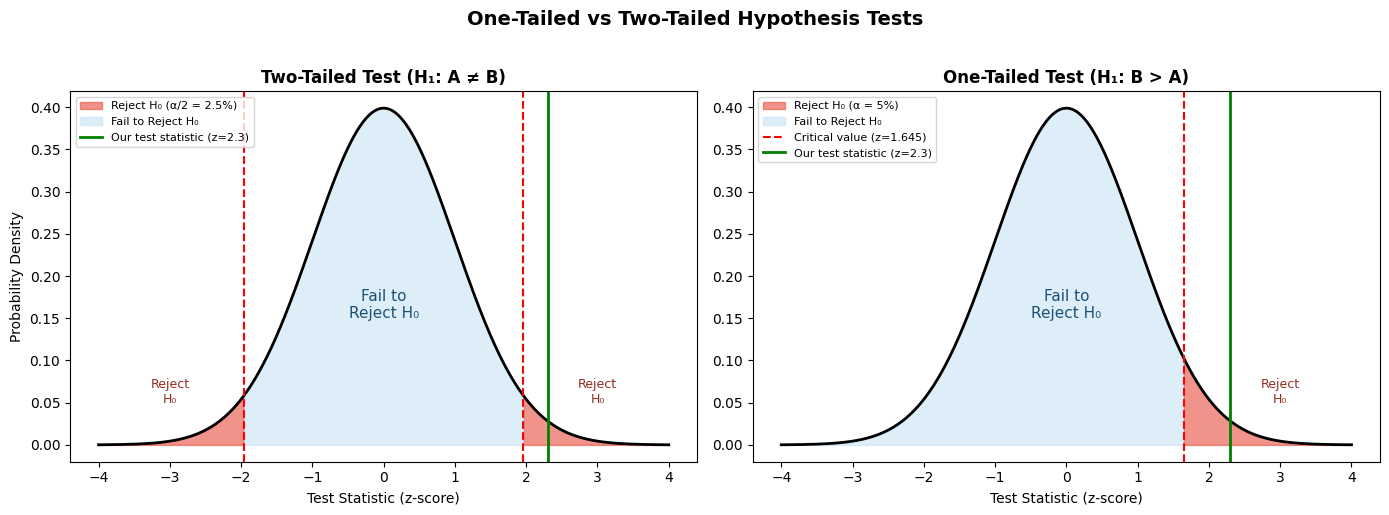

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

# ── Plot 1: Two-tailed test ──────────────────────────────
ax = axes[0]
ax.plot(x, y, 'k-', linewidth=2)
ax.fill_between(x, y, where=(x <= -1.96), color='#E74C3C', alpha=0.6, label='Reject H₀ (α/2 = 2.5%)')
ax.fill_between(x, y, where=(x >= 1.96),  color='#E74C3C', alpha=0.6)
ax.fill_between(x, y, where=((x > -1.96) & (x < 1.96)), color='#AED6F1', alpha=0.4, label='Fail to Reject H₀')
ax.axvline(-1.96, color='red', linestyle='--', linewidth=1.5)
ax.axvline( 1.96, color='red', linestyle='--', linewidth=1.5)
ax.axvline(2.3, color='green', linestyle='-', linewidth=2, label='Our test statistic (z=2.3)')
ax.set_title('Two-Tailed Test (H₁: A ≠ B)', fontsize=12, fontweight='bold')
ax.set_xlabel('Test Statistic (z-score)')
ax.set_ylabel('Probability Density')
ax.legend(fontsize=8)
ax.text(0, 0.15, 'Fail to\nReject H₀', ha='center', fontsize=11, color='#1A5276')
ax.text(-3, 0.05, 'Reject\nH₀', ha='center', fontsize=9, color='#922B21')
ax.text( 3, 0.05, 'Reject\nH₀', ha='center', fontsize=9, color='#922B21')

# ── Plot 2: One-tailed test ──────────────────────────────
ax = axes[1]
ax.plot(x, y, 'k-', linewidth=2)
ax.fill_between(x, y, where=(x >= 1.645), color='#E74C3C', alpha=0.6, label='Reject H₀ (α = 5%)')
ax.fill_between(x, y, where=(x < 1.645),  color='#AED6F1', alpha=0.4, label='Fail to Reject H₀')
ax.axvline(1.645, color='red', linestyle='--', linewidth=1.5, label='Critical value (z=1.645)')
ax.axvline(2.3,   color='green', linestyle='-', linewidth=2, label='Our test statistic (z=2.3)')
ax.set_title('One-Tailed Test (H₁: B > A)', fontsize=12, fontweight='bold')
ax.set_xlabel('Test Statistic (z-score)')
ax.legend(fontsize=8)
ax.text(0, 0.15, 'Fail to\nReject H₀', ha='center', fontsize=11, color='#1A5276')
ax.text(3, 0.05, 'Reject\nH₀', ha='center', fontsize=9, color='#922B21')

plt.suptitle('One-Tailed vs Two-Tailed Hypothesis Tests', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hypothesis_tests.png', dpi=150, bbox_inches='tight')
plt.show()



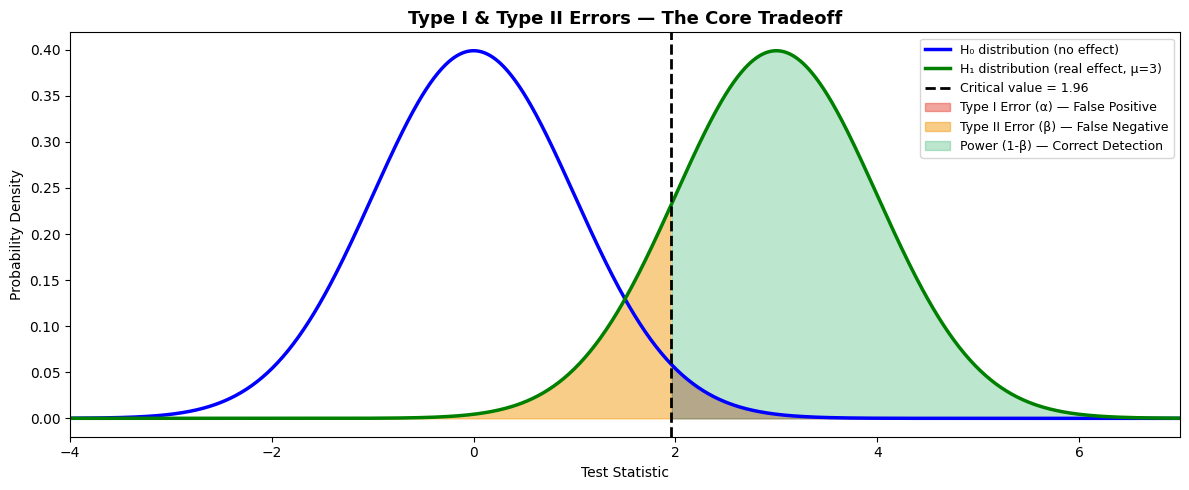

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.linspace(-5, 8, 1000)

# H₀ distribution (no effect, mean=0)
h0 = stats.norm.pdf(x, loc=0, scale=1)
# H₁ distribution (real effect, mean=3)
h1 = stats.norm.pdf(x, loc=3, scale=1)

critical_value = 1.96

ax.plot(x, h0, 'b-',  linewidth=2.5, label='H₀ distribution (no effect)')
ax.plot(x, h1, 'g-',  linewidth=2.5, label='H₁ distribution (real effect, μ=3)')
ax.axvline(critical_value, color='black', linestyle='--', linewidth=2, label=f'Critical value = {critical_value}')

# Type I Error — right tail of H₀ beyond critical value
ax.fill_between(x, h0, where=(x >= critical_value),
                color='#E74C3C', alpha=0.5, label='Type I Error (α) — False Positive')

# Type II Error — left tail of H₁ before critical value
ax.fill_between(x, h1, where=(x <= critical_value),
                color='#F39C12', alpha=0.5, label='Type II Error (β) — False Negative')

# Power
ax.fill_between(x, h1, where=(x >= critical_value),
                color='#27AE60', alpha=0.3, label='Power (1-β) — Correct Detection')

ax.set_title('Type I & Type II Errors — The Core Tradeoff', fontsize=13, fontweight='bold')
ax.set_xlabel('Test Statistic')
ax.set_ylabel('Probability Density')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-4, 7)

plt.tight_layout()
plt.savefig('type1_type2_errors.png', dpi=150, bbox_inches='tight')
plt.show()